---

# `Streamlitapp.py`
```Python
import os
import streamlit as st
from crewai import Agent, Task, Crew, LLM
from crewai_tools import SerperDevTool
from dotenv import load_dotenv

# Load environment variables
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")
os.environ["CREWAI_TELEMETRY_DISABLED"] = os.getenv("CREWAI_TELEMETRY_DISABLED")

# Streamlit page config
st.set_page_config(page_title="Content Reseracher &  Writer", page_icon="📰", layout="wide")

# Title and description
st.title("🤖 Content Researcher & Writer, powered by CrewAI")
st.markdown("Generate blog posts about any topic using AI agents.")

# Sidebar
with st.sidebar:
    st.header("Content Settings")

    # Make the text input take up more space
    topic = st.text_area(
        "Enter your topic",
        height=100,
        placeholder="Enter the topic"
    )

    # Add more sidebar controls if needed
    st.markdown("### LLM Settings")
    temperature = st.slider("Temperature", 0.0, 1.0, 0.7)

    # Add some spacing
    st.markdown("---")

    # Make the generate button more prominent in the sidebar
    generate_button = st.button("Generate Content", type="primary", use_container_width=True)

    # Add some helpful information
    with st.expander("ℹ️ How to use"):
        st.markdown("""
        1. Enter your desired content topic
        2. Play with the temperature
        3. Click 'Generate Content' to start
        4. Wait for the AI to generate your article
        5. Download the result as a markdown file
        """)

########################## CREWAI APP ##########################

def generate_content(topic):
    llm = LLM(
        model="gemini/gemini-2.5-flash",
        api_key= os.getenv("GOOGLE_API_KEY")
    )

    search_tool = SerperDevTool(n_results=1)

    # First Agent: Senior Research Analyst
    senior_research_analyst = Agent(
        role="Senior Research Analyst",
        goal=f"Research, analyze, and synthesize comprehensive information on {topic} from reliable web sources",
        backstory="You're an expert research analyst with advanced web research skills. "
                "You excel at finding, analyzing, and synthesizing information from "
                "across the internet using search tools. You're skilled at "
                "distinguishing reliable sources from unreliable ones, "
                "fact-checking, cross-referencing information, and "
                "identifying key patterns and insights. You provide "
                "well-organized research briefs with proper citations "
                "and source verification. Your analysis includes both "
                "raw data and interpreted insights, making complex "
                "information accessible and actionable.",
        allow_delegation=False,
        verbose=True,
        tools=[search_tool],
        llm=llm
    )

    # Second Agent: Content Writer
    content_writer = Agent(
        role="Content Writer",
        goal="Transform research findings into engaging blog posts while maintaining accuracy",
        backstory="You're a skilled content writer specialized in creating "
                "engaging, accessible content from technical research. "
                "You work closely with the Senior Research Analyst and excel at maintaining the perfect "
                "balance between informative and entertaining writing, "
                "while ensuring all facts and citations from the research "
                "are properly incorporated. You have a talent for making "
                "complex topics approachable without oversimplifying them.",
        allow_delegation=False,
        verbose=True,
        llm=llm
    )

    # Research Task
    research_task = Task(
        description=("""
            1. Conduct comprehensive research on {topic} including:
                - Recent developments and news
                - Key industry trends and innovations
                - Expert opinions and analyses
                - Statistical data and market insights
            2. Evaluate source credibility and fact-check all information
            3. Organize findings into a structured research brief
            4. Include all relevant citations and sources
        """),
        expected_output="""A detailed research report containing:
            - Executive summary of key findings
            - Comprehensive analysis of current trends and developments
            - List of verified facts and statistics
            - All citations and links to original sources
            - Clear categorization of main themes and patterns
            Please format with clear sections and bullet points for easy reference.""",
        agent=senior_research_analyst
    )

    # Writing Task
    writing_task = Task(
        description=("""
            Using the research brief provided, create an engaging blog post that:
            1. Transforms technical information into accessible content
            2. Maintains all factual accuracy and citations from the research
            3. Includes:
                - Attention-grabbing introduction
                - Well-structured body sections with clear headings
                - Compelling conclusion
            4. Preserves all source citations in [Source: URL] format
            5. Includes a References section at the end
        """),
        expected_output="""A polished blog post in markdown format that:
            - Engages readers while maintaining accuracy
            - Contains properly structured sections
            - Includes Inline citations hyperlinked to the original source url
            - Presents information in an accessible yet informative way
            - Follows proper markdown formatting, use H1 for the title and H3 for the sub-sections""",
        agent=content_writer
    )

    # Create Crew
    crew = Crew(
        agents=[senior_research_analyst, content_writer],
        tasks=[research_task, writing_task],
        verbose=True
    )

    return crew.kickoff(inputs={"topic": topic})

# Main content area
if generate_button:
    with st.spinner('Generating content... This may take a moment.'):
        try:
            result = generate_content(topic)
            st.markdown("### Generated Content")
            st.markdown(result)

            # Add download button
            st.download_button(
                label="Download Content",
                data=result.raw,
                file_name=f"{topic.lower().replace(' ', '_')}_article.md",
                mime="text/markdown"
            )
        except Exception as e:
            st.error(f"An error occurred: {str(e)}")

# Footer
st.markdown("---")
st.markdown("Built with CrewAI, Streamlit and ChatGPT")
```

----

## `Streamlitapp.output-1`
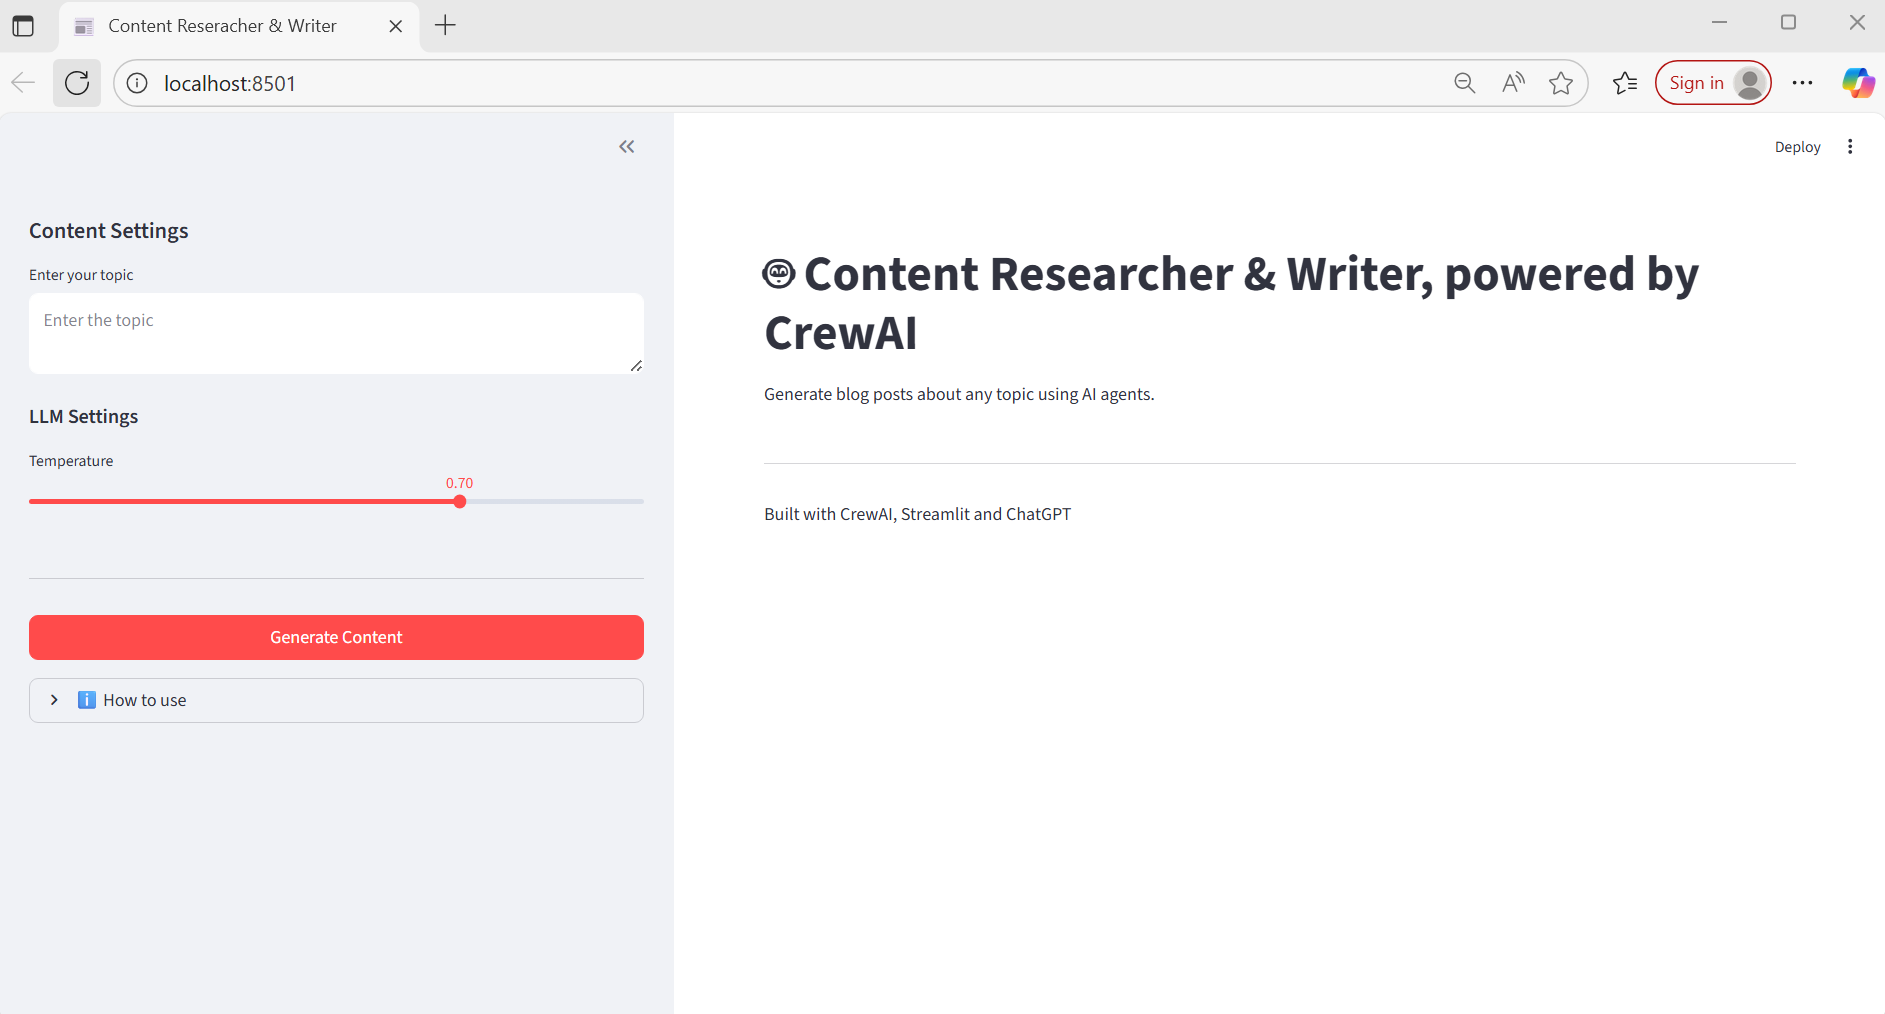 <br><br> 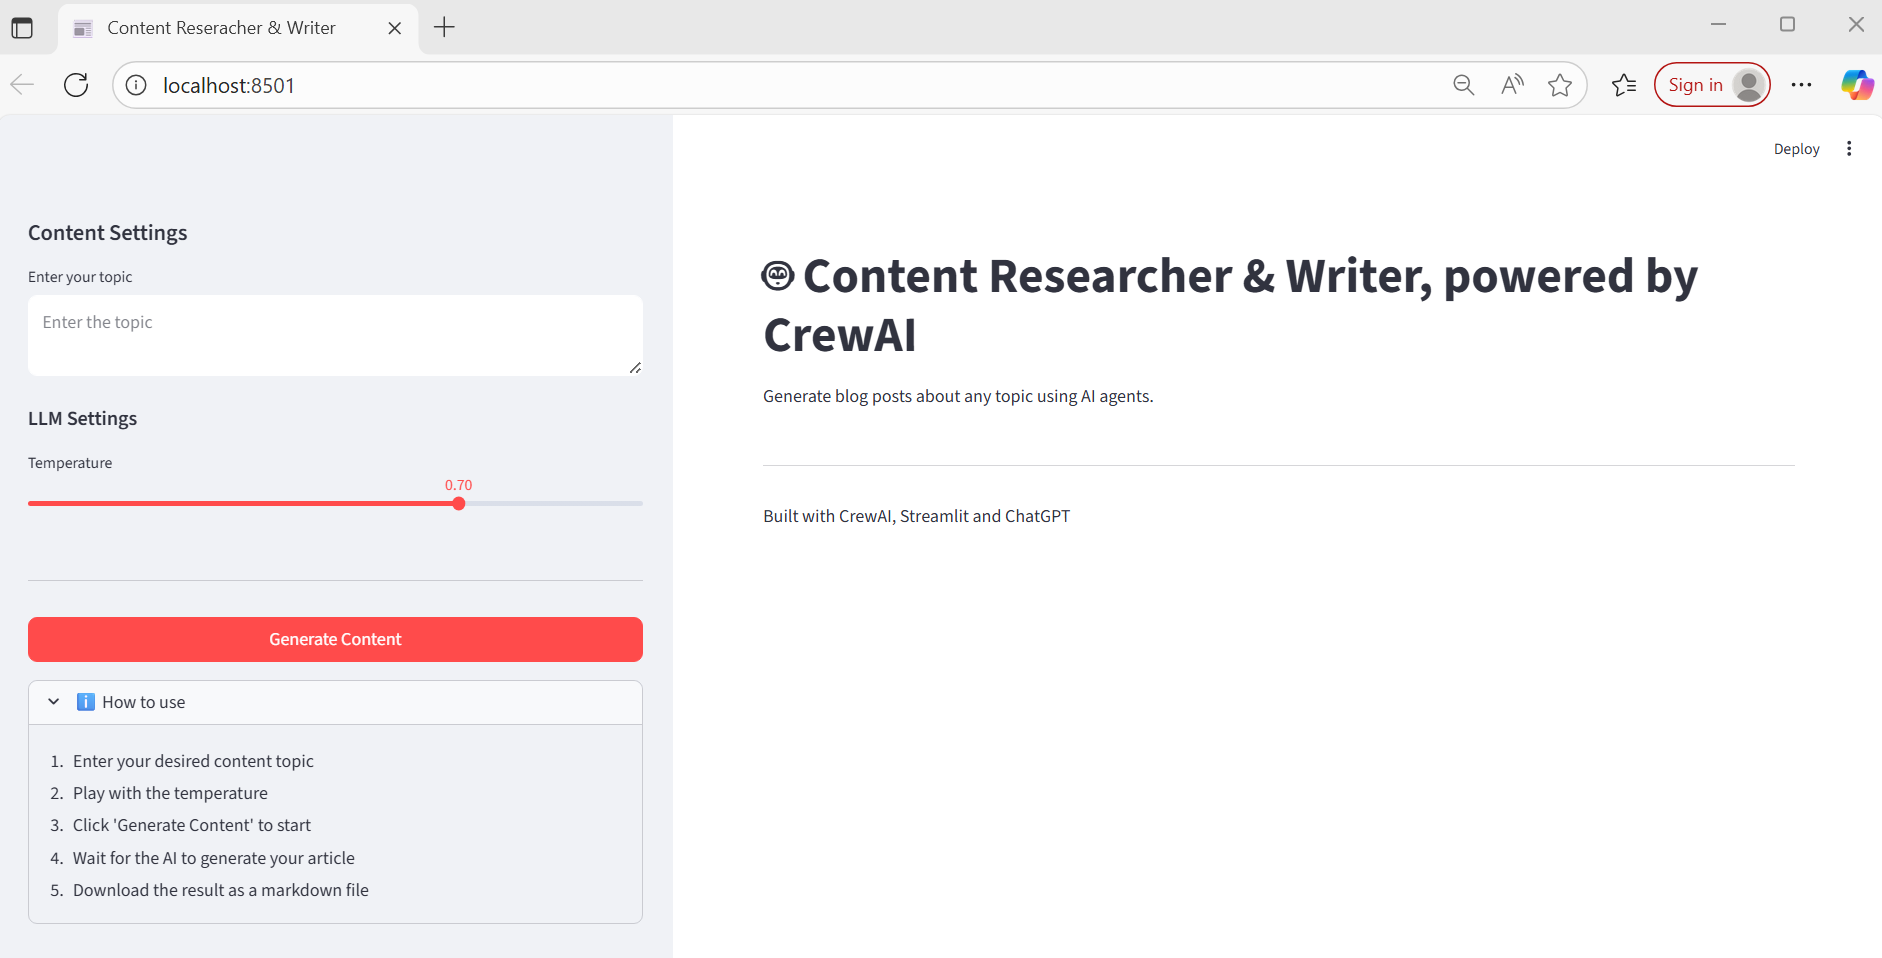 <br><br>
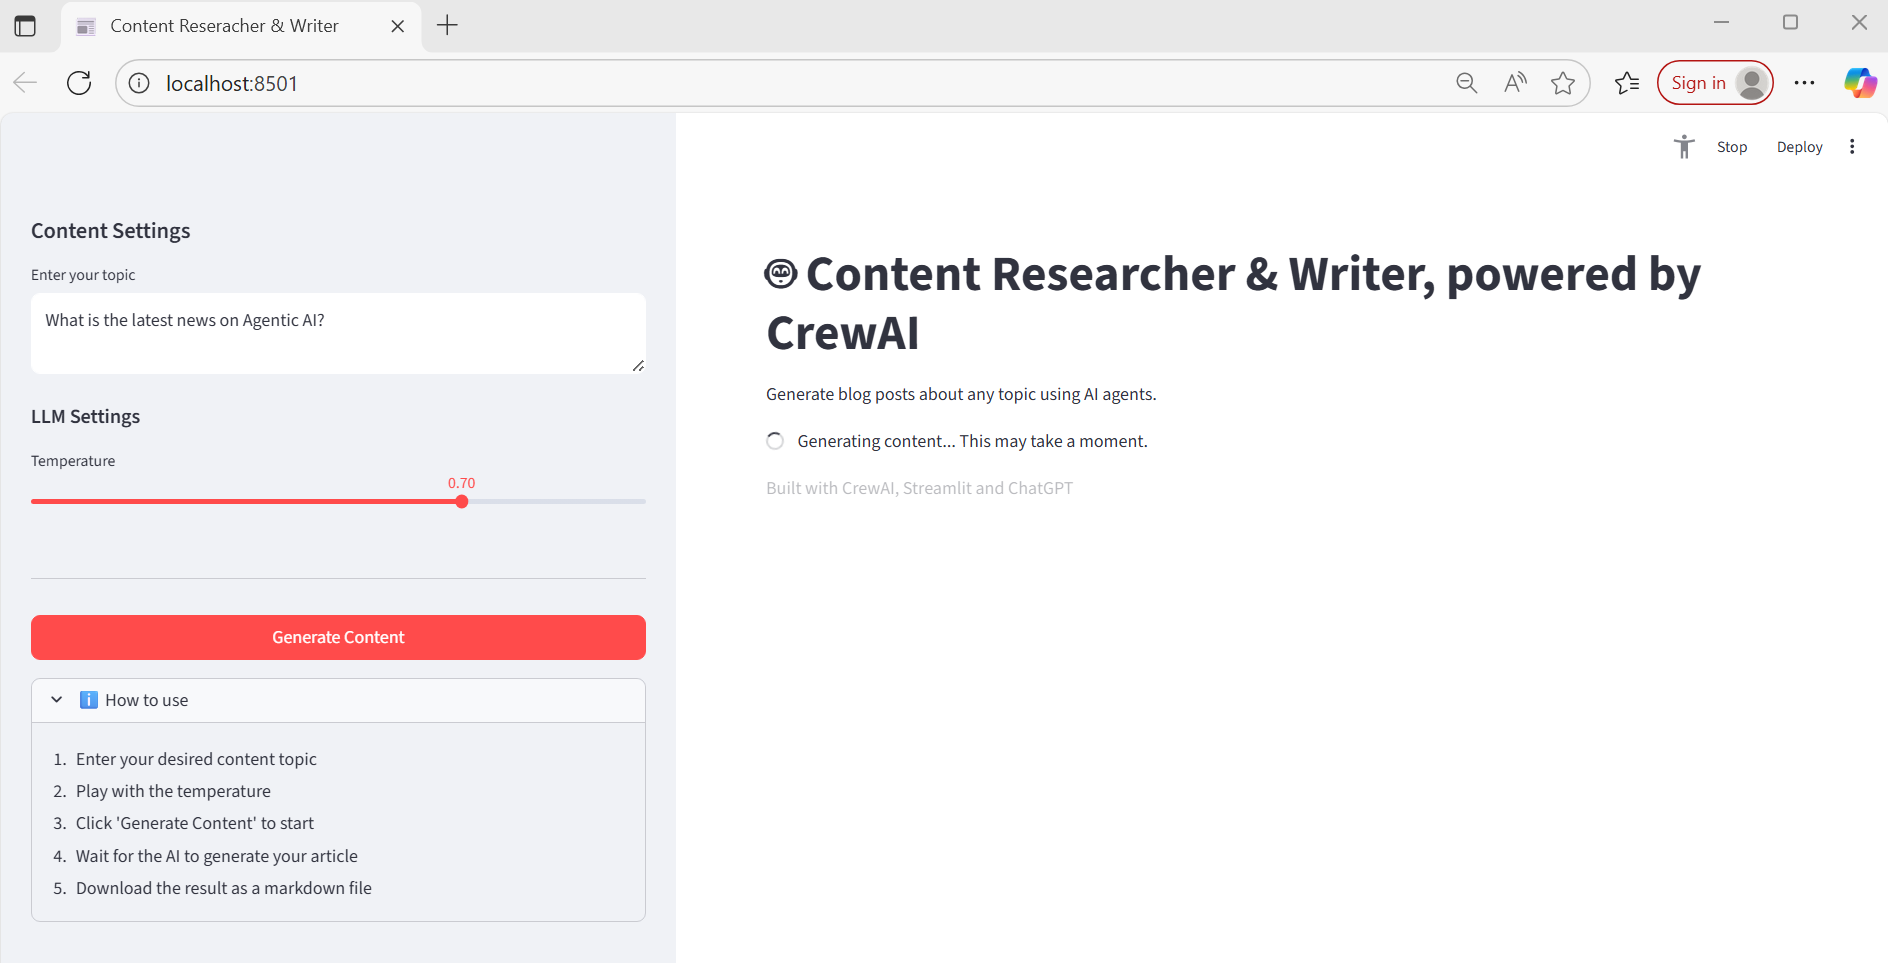 <br><br> 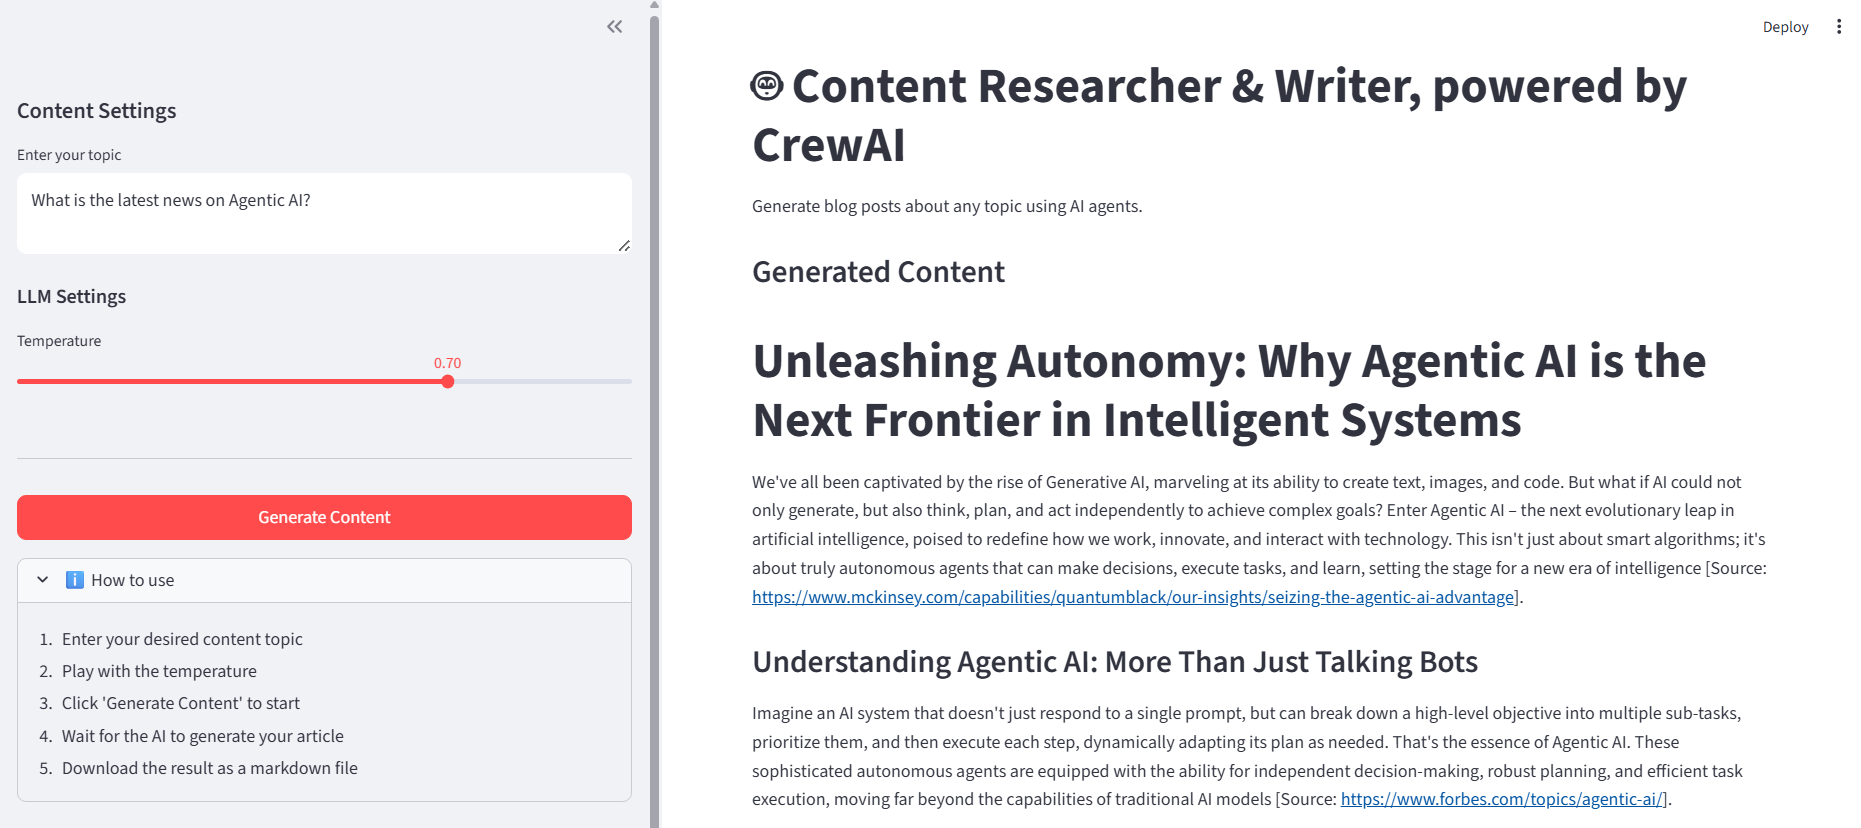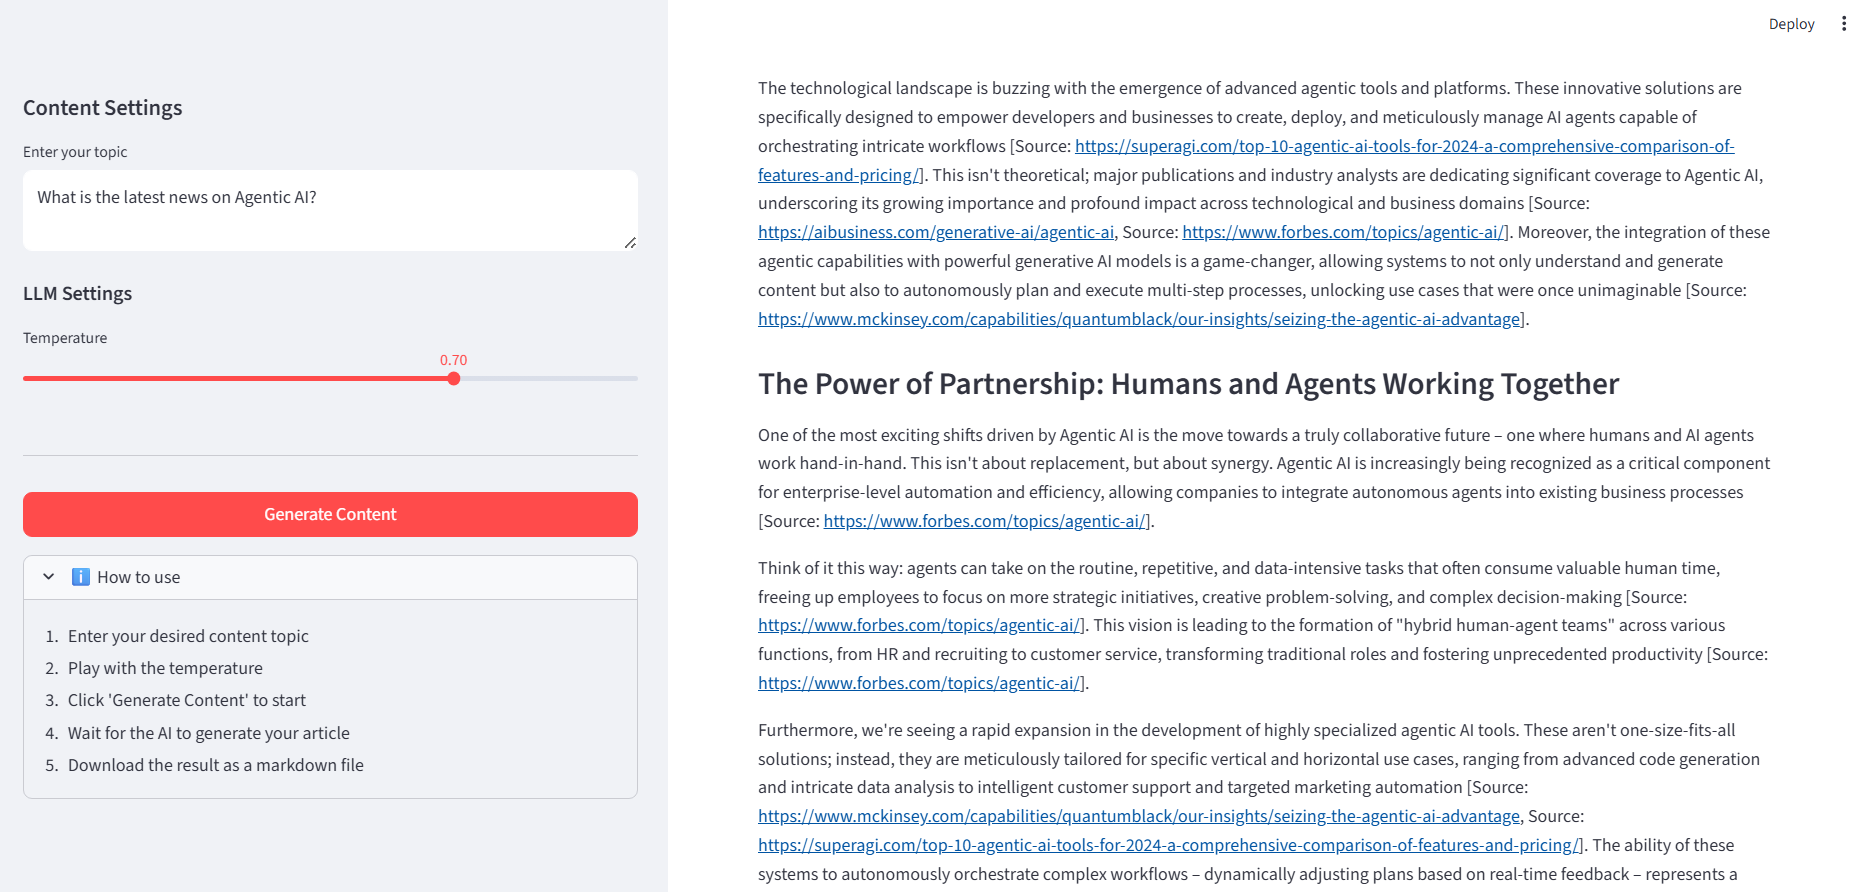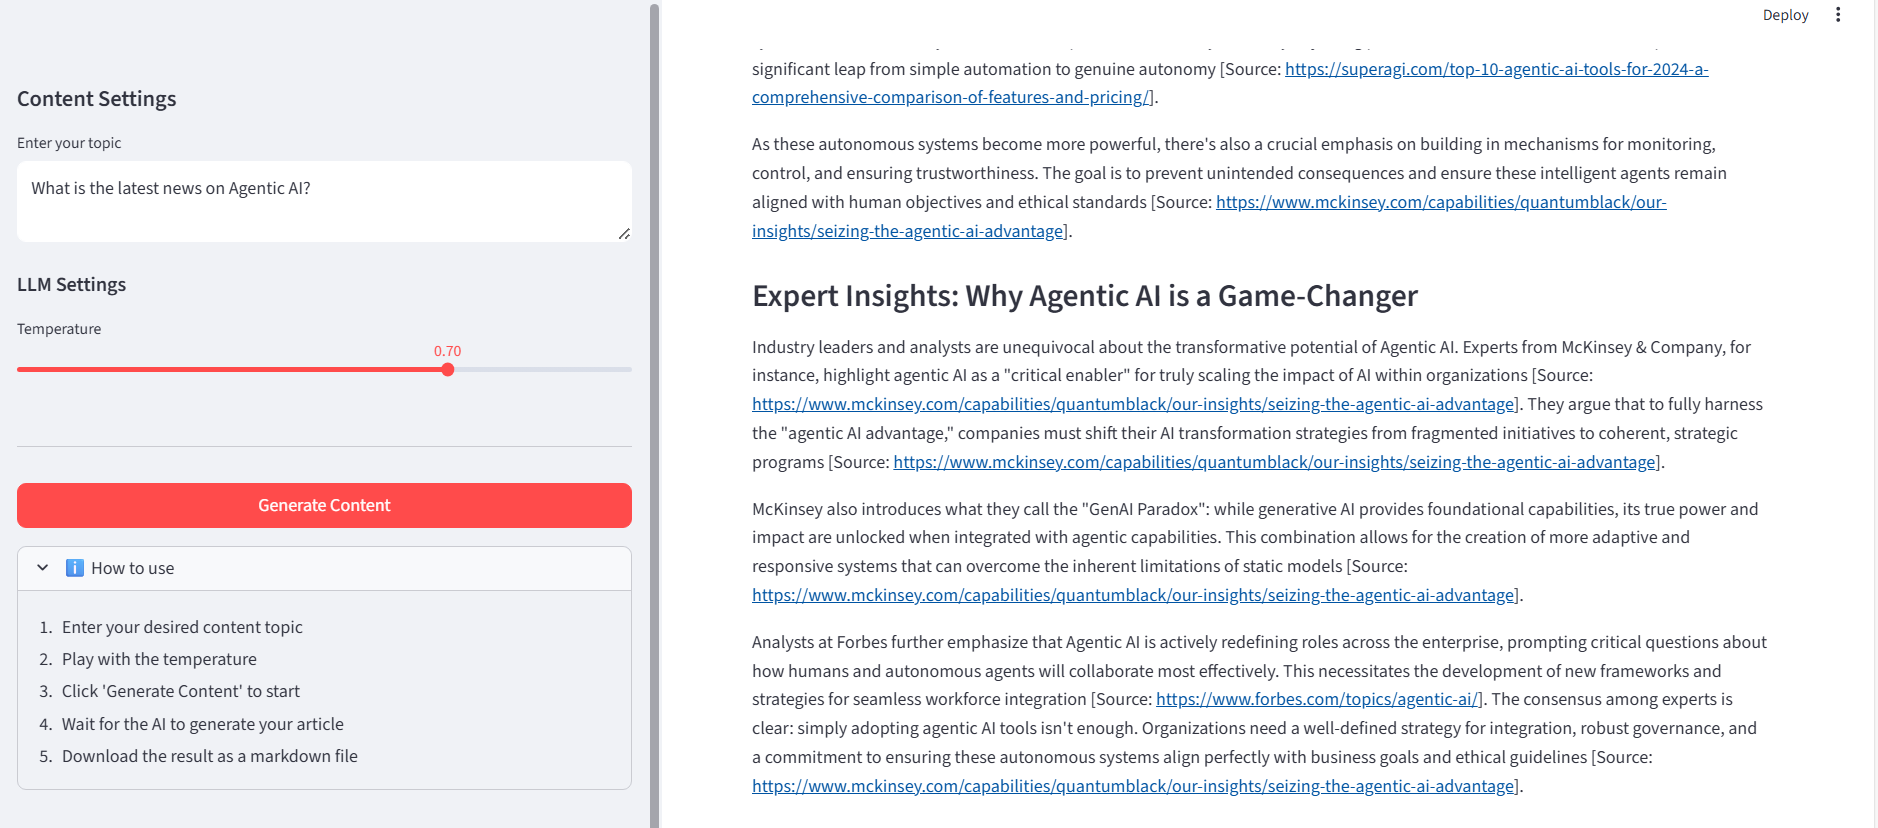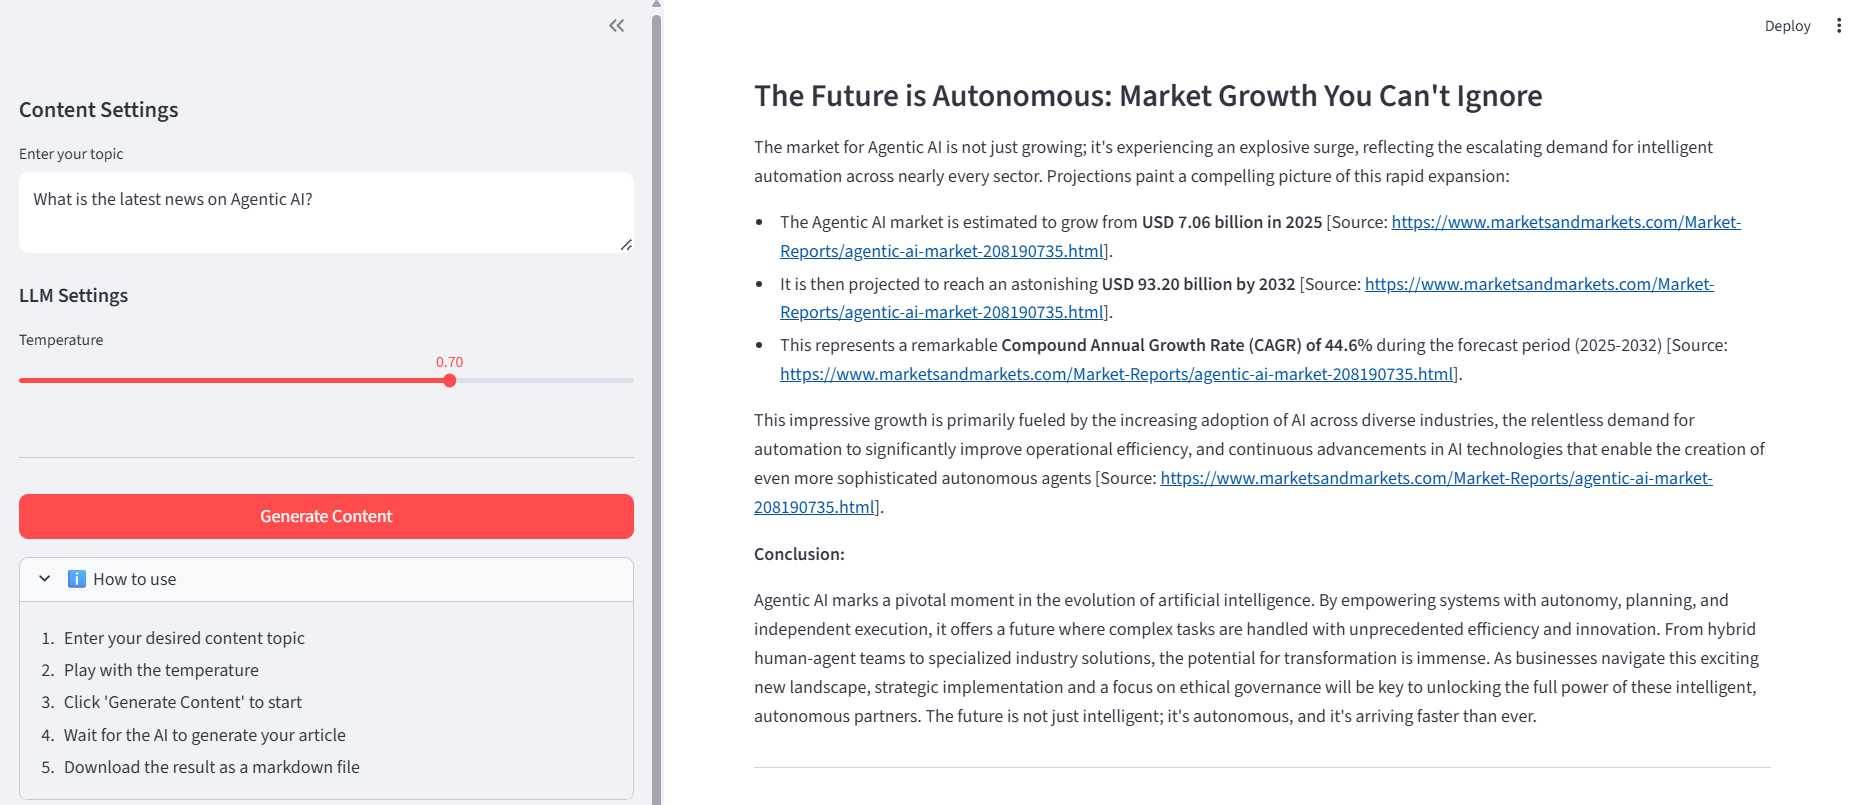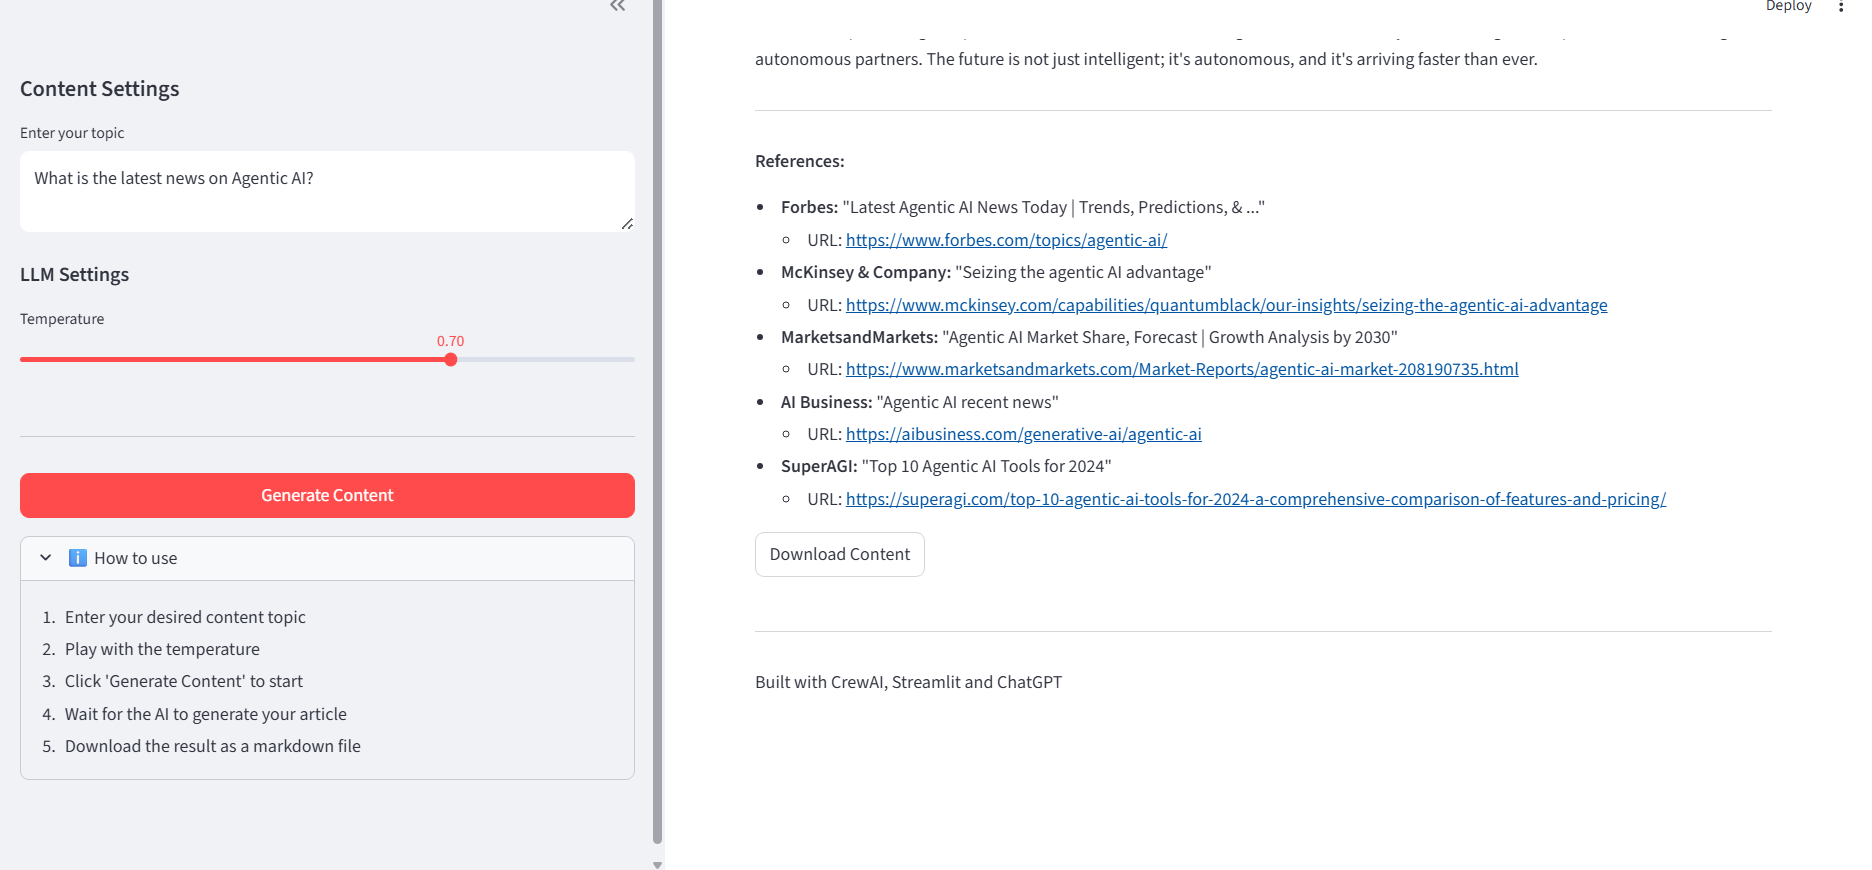

---
### **Crew Completion**
`Crew Execution Completed` <br>  `Name`: crew <br> `ID`: b171d86d-8799-41f5-8a0e-b940952b6634 <br> `Tool Args:` <br>
`Final Output`: # Beyond Automation: How Agentic AI is Reshaping Industries and Unlocking New Value <br><br>

Remember when AI was just about automating repetitive tasks or answering simple queries? Get ready for a game-changer. Artificial intelligence is     │
│  taking its next giant leap forward with the emergence of **Agentic AI**. These aren't your typical chatbots or algorithms; Agentic AI systems are     │
│  designed to autonomously plan, reason, and execute complex, multi-step tasks to achieve high-level goals. Imagine an AI that doesn't just do what     │
│  you tell it, but figures out *how* to achieve an objective, breaks it down into sub-tasks, and learns along the way. This revolutionary approach      │
│  promises to transform businesses, create new revenue streams, and redefine the very nature of work.

### What Makes Agentic AI Different?                                                                                                                  │
│                                                                                                                                                        │
│  The true power of Agentic AI lies in its inherent autonomy and goal-oriented nature. Unlike traditional AI, which often requires explicit             │
│  instructions for each step, agentic systems can comprehend a high-level objective and then intelligently decompose it into a series of smaller,       │
│  manageable sub-tasks. They learn, adapt, and make decisions independently to reach the desired outcome. This capability moves AI beyond simple        │
│  reactive tools to proactive, strategic partners capable of sophisticated problem-solving. This field is dynamic, with ongoing research focusing on    │
│  improving agent reliability, safety, and their ability to handle ambiguous or evolving goals [Source:                                                 │
│  https://aibusiness.com/generative-ai/agentic-ai].                                                                                                     │
│                                                                                                                                                        │
│  ### The Dawn of "Agentic Organizations"                                                                                                               │
│                                                                                                                                                        │
│  This shift isn't just about new technology; it's about a new way of working. Companies are rapidly embracing what's being called the "agentic         │
│  organization" operating model. Here, human teams don't just use AI as a tool; they collaborate seamlessly with virtual and even physical AI agents    │
│  to tackle complex challenges and automate intricate processes. McKinsey highlights this paradigm as moving AI beyond mere productivity tools,         │
│  transforming them into "strategic revenue engines" [Source:                                                                                           │
│  https://www.mckinsey.com/capabilities/people-and-organizational-performance/our-insights/the-agentic-organization-contours-of-the-next-paradigm-for-  │
│  the-ai-era]. It's a fundamental re-imagination of how businesses can leverage AI for strategic growth and reshape existing cost structures.           │
│                                                                                                                                                        │
│  ### Agentic AI: Empowering Industries, Redefining Roles                                                                                               │
│                                                                                                                                                        │
│  The impact of Agentic AI isn't confined to a single sector; its potential is being explored and implemented across a diverse range of advanced        │
│  industries. From automotive and manufacturing to crucial enterprise functions like Human Resources and recruiting, agentic systems are poised to      │
│  empower operations and drive innovation. McKinsey notes its potential to "empower advanced industries" [Source:                                       │
│  https://www.mckinsey.com/industries/automotive-and-assembly/our-insights/empowering-advanced-industries-with-agentic-ai], while Forbes points to it   │
│  "reshaping the enterprise" by creating hybrid human-agent teams and redefining roles [Source: https://www.forbes.com/topics/agentic-ai/]. This        │
│  widespread integration signifies a profound shift in how work gets done and how teams are structured, raising questions about how humans and          │
│  autonomous agents will effectively collaborate.                                                                                                       │
│                                                                                                                                                        │
│  ### An Explosive Market Growth Ahead                                                                                                                  │
│                                                                                                                                                        │
│  The industry’s confidence in Agentic AI is reflected in its staggering market projections. According to MarketsandMarkets, the Agentic AI market is   │
│  set for explosive growth, projected to soar from USD 7.06 billion in 2025 to an impressive USD 93.20 billion by 2032 [Source:                         │
│  https://www.marketsandmarkets.com/Market-Reports/agentic-ai-market-208190735.html]. This represents a phenomenal Compound Annual Growth Rate (CAGR)   │
│  of 44.6% during the forecast period (2025-2032), underscoring the immense potential and anticipated adoption of these sophisticated AI systems        │
│  across the globe [Source: https://www.marketsandmarkets.com/Market-Reports/agentic-ai-market-208190735.html].                                         │
│                                                                                                                                                        │
│  ### Expert Perspectives: Beyond Productivity, Towards Transformation                                                                                  │
│                                                                                                                                                        │
│  Experts universally agree that Agentic AI represents a pivotal moment in the evolution of artificial intelligence. McKinsey emphasizes that it's      │
│  more than just a productivity enhancer; it's a "new revenue engine" and a "strategic lever" capable of reshaping cost structures and driving          │
│  significant value for organizations [Source:                                                                                                          │
│  https://www.mckinsey.com/capabilities/people-and-organizational-performance/our-insights/the-agentic-organization-contours-of-the-next-paradigm-for-  │
│  the-ai-era]. Forbes echoes this sentiment, highlighting how Agentic AI will "reshape the enterprise," creating new hybrid teams and sparking          │
│  critical questions about how humans and autonomous agents will effectively collaborate to co-create value [Source:                                    │
│  https://www.forbes.com/topics/agentic-ai/]. The overarching consensus, across platforms like AI Business, Forbes, and McKinsey, is that Agentic AI    │
│  heralds a truly transformative shift, offering a level of sophisticated automation and problem-solving previously unseen in AI capabilities [Source:  │
│  https://aibusiness.com/generative-ai/agentic-ai].                                                                                                     │
│                                                                                                                                                        │
│  ### The Autonomous Revolution is Here                                                                                                                 │
│                                                                                                                                                        │
│  Agentic AI is undeniably ushering in a new era of intelligence – one defined by autonomy, strategic problem-solving, and seamless human-AI            │
│  collaboration. From its ability to break down complex goals into actionable steps to its projected market explosion, this technology is poised to     │
│  fundamentally alter our industries and redefine the very fabric of enterprise operations. While the opportunities for innovation and efficiency are   │
│  vast, ongoing research continues to refine agent reliability, safety, and ethical considerations. The future of work is not just about using AI;      │
│  it's about collaborating with it, and Agentic AI is setting the stage for this exciting, autonomous revolution.                                       │
│                                                                                                                                                        │
│  ---                                                                                                                                                   │
│                                                                                                                                                        │
│  ### References                                                                                                                                        │
│  *   **AI Business:** "Agentic AI recent news" [https://aibusiness.com/generative-ai/agentic-ai](https://aibusiness.com/generative-ai/agentic-ai)      │
│  *   **McKinsey & Company:** "Empowering advanced industries with agentic AI"                                                                          │
│  [https://www.mckinsey.com/industries/automotive-and-assembly/our-insights/empowering-advanced-industries-with-agentic-ai](https://www.mckinsey.com/i  │
│  ndustries/automotive-and-assembly/our-insights/empowering-advanced-industries-with-agentic-ai)                                                        │
│  *   **McKinsey & Company:** "The agentic organization: A new operating model for AI"                                                                  │
│  [https://www.mckinsey.com/capabilities/people-and-organizational-performance/our-insights/the-agentic-organization-contours-of-the-next-paradigm-for  │
│  -the-ai-era](https://www.mckinsey.com/capabilities/people-and-organizational-performance/our-insights/the-agentic-organization-contours-of-the-next-  │
│  paradigm-for-the-ai-era)                                                                                                                              │
│  *   **MarketsandMarkets:** "Agentic AI Market Share, Forecast | Growth Analysis by 2030"                                                              │
│  [https://www.marketsandmarkets.com/Market-Reports/agentic-ai-market-208190735.html](https://www.marketsandmarkets.com/Market-Reports/agentic-ai-mark  │
│  et-208190735.html)                                                                                                                                    │
│  *   **Forbes:** "Latest Agentic AI News Today | Trends, Predictions, & ..."                                                                           │
│  [https://www.forbes.com/topics/agentic-ai/](https://www.forbes.com/topics/agentic-ai/)                                                                │
│                                                                                         

---
## `Streamlitapp.output-2`
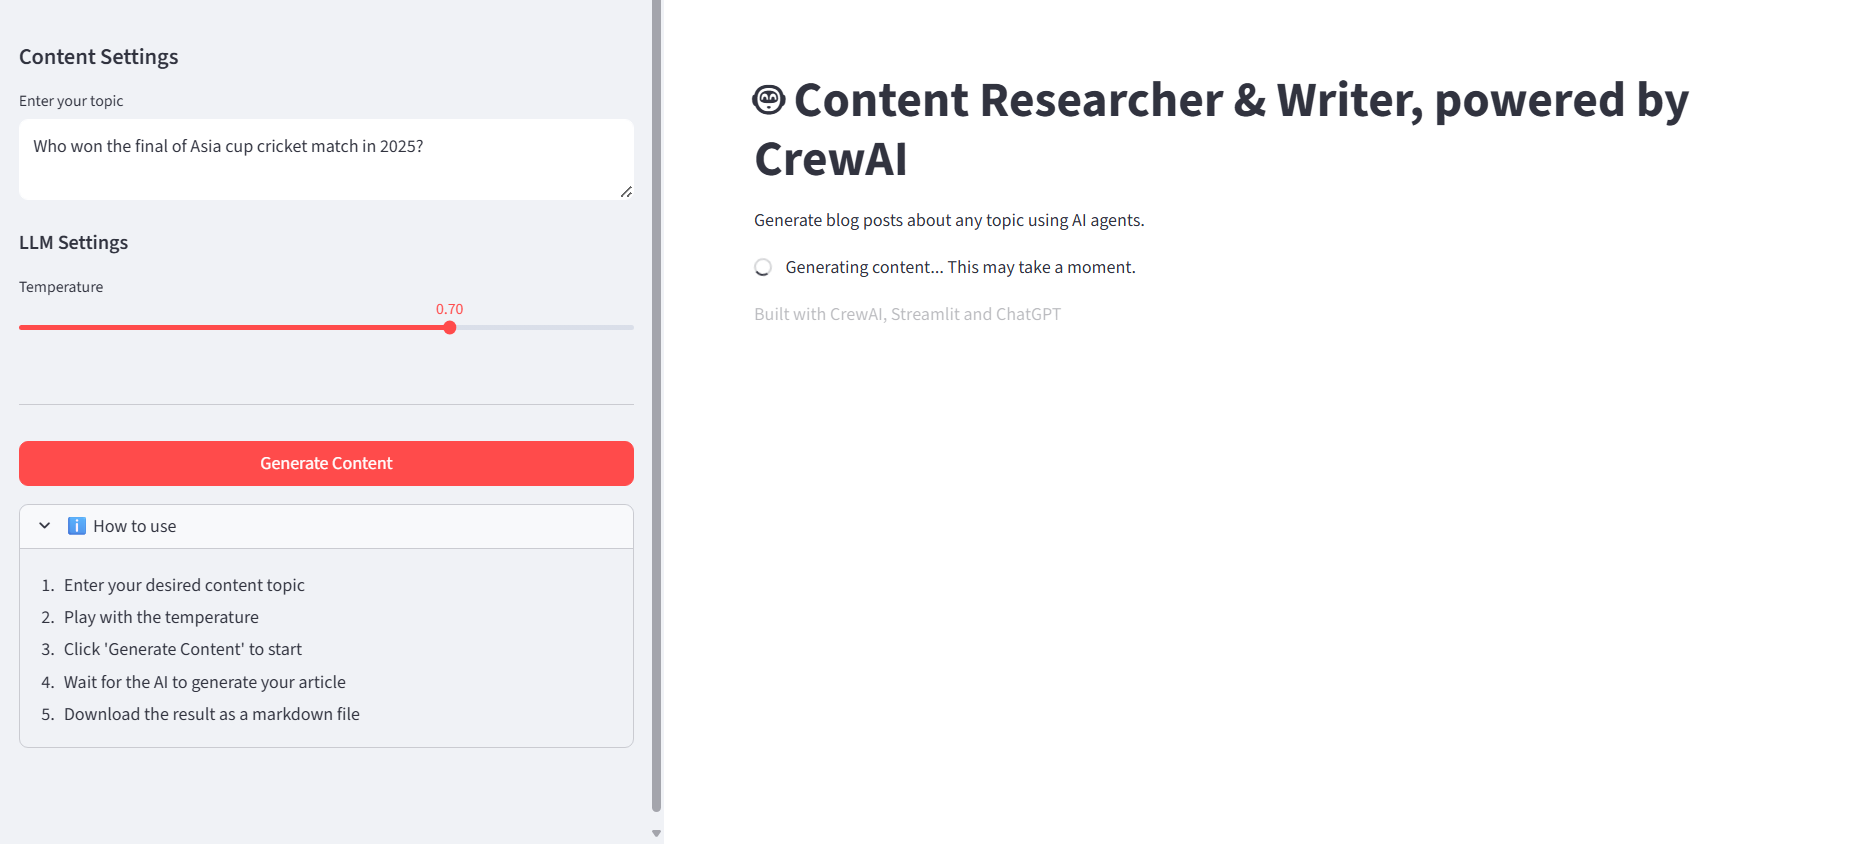 <br><br> 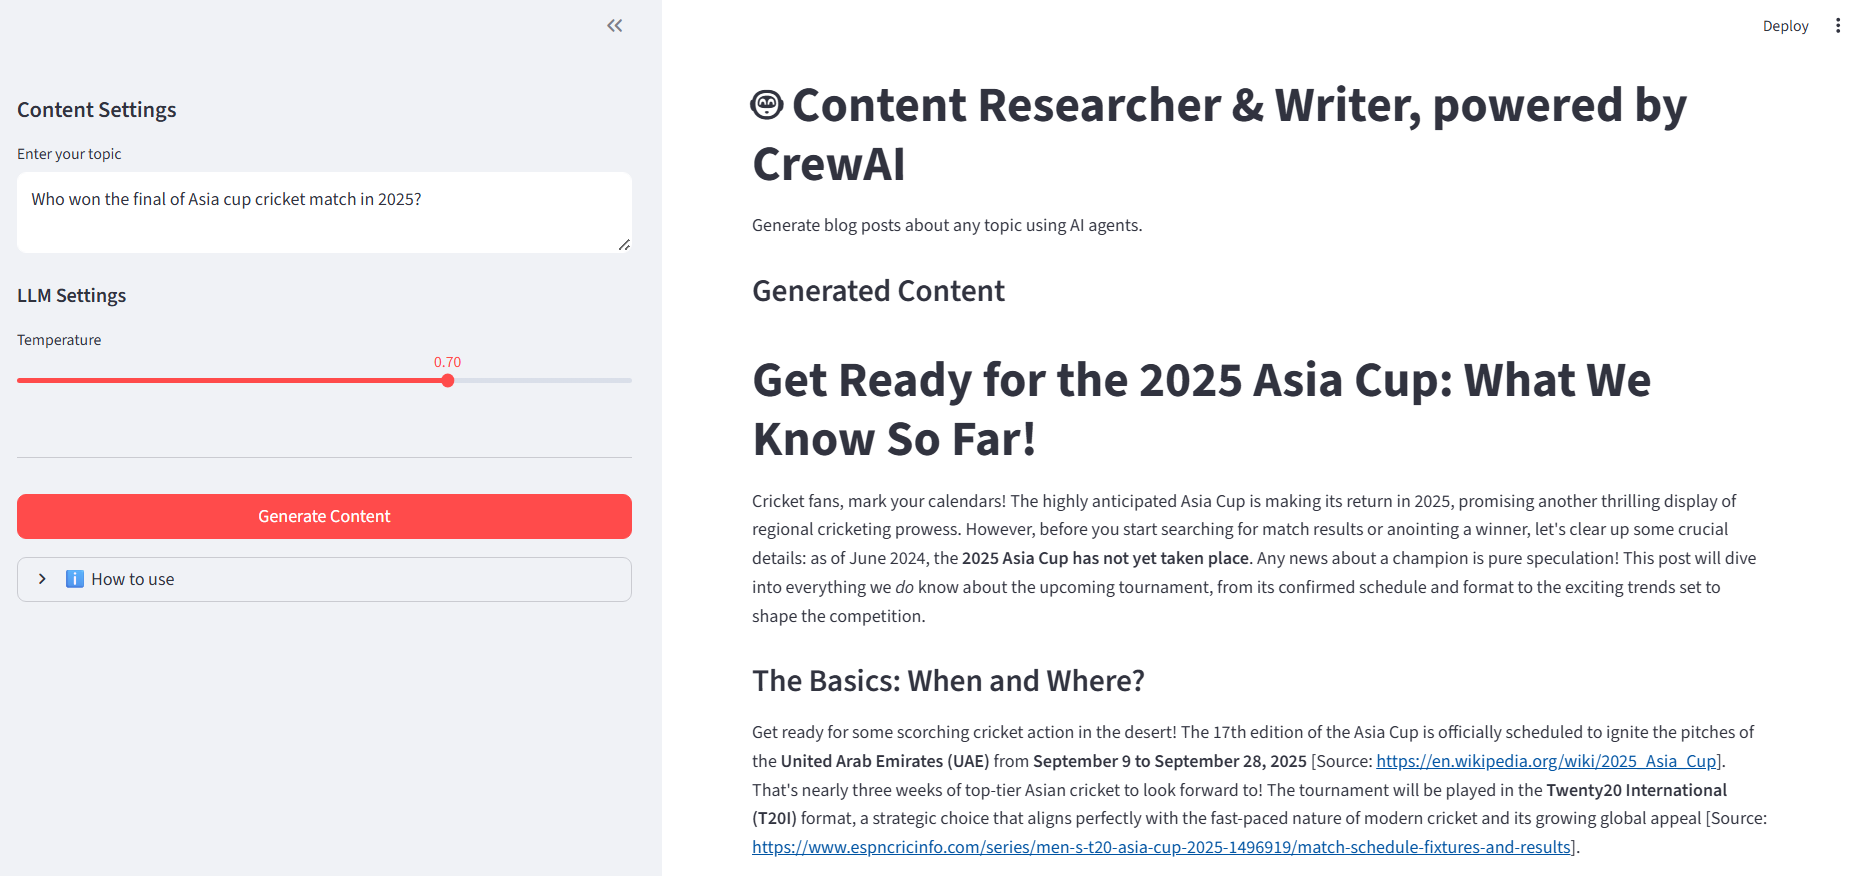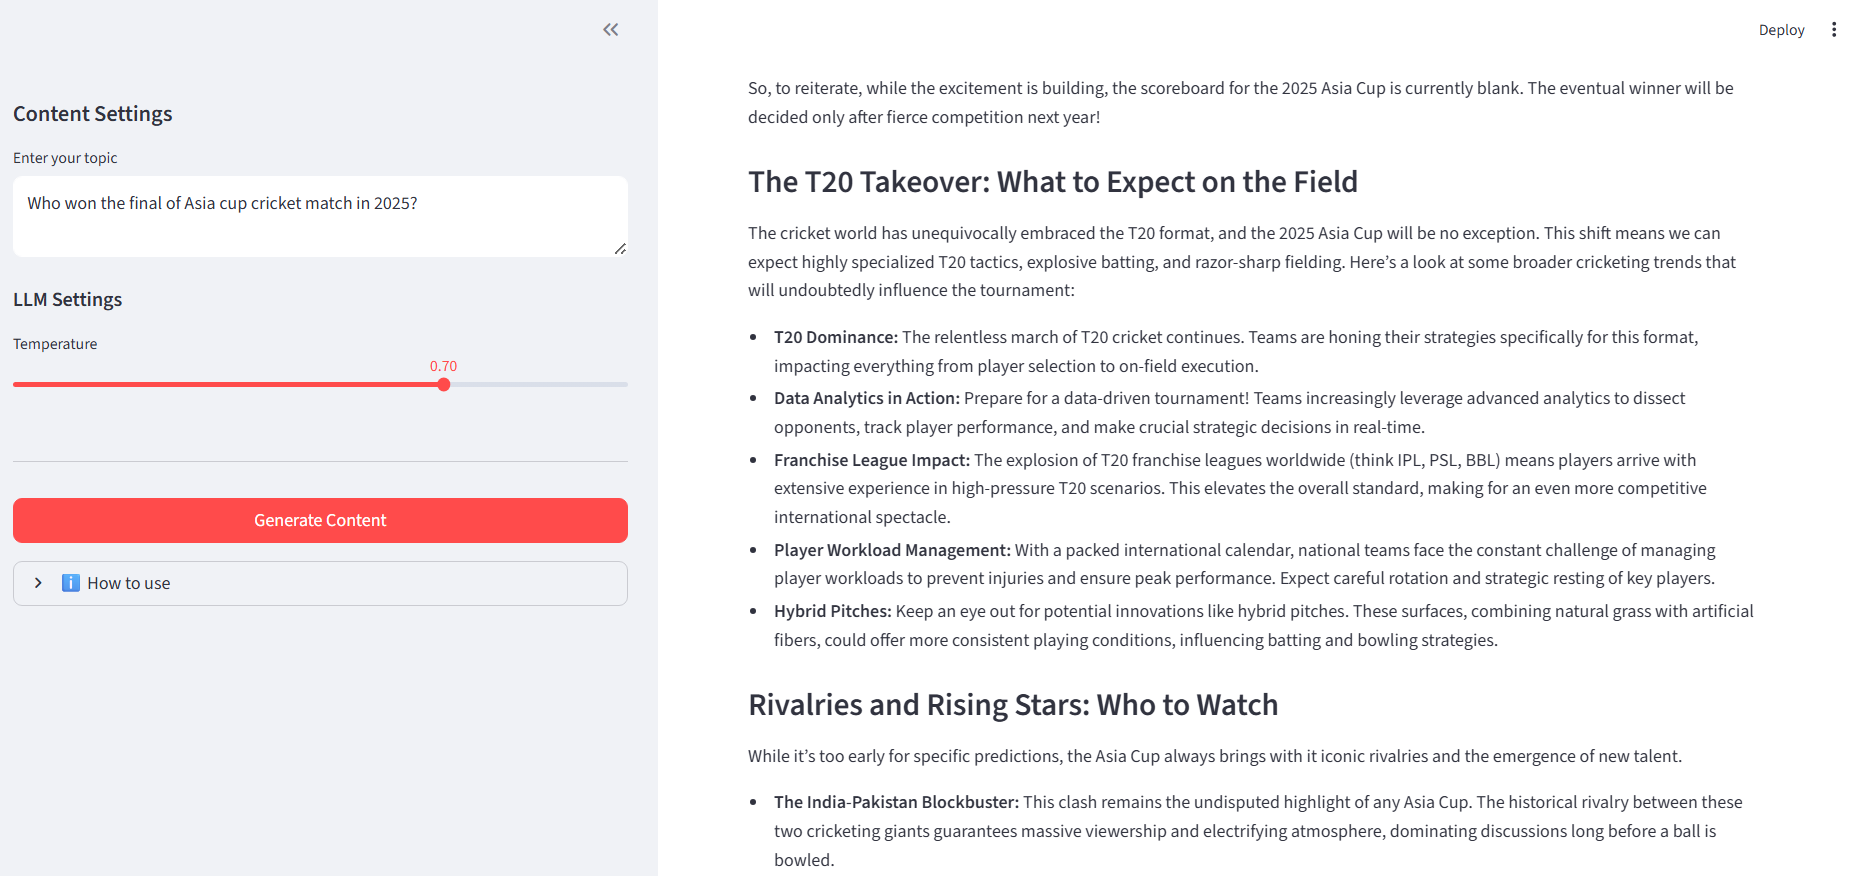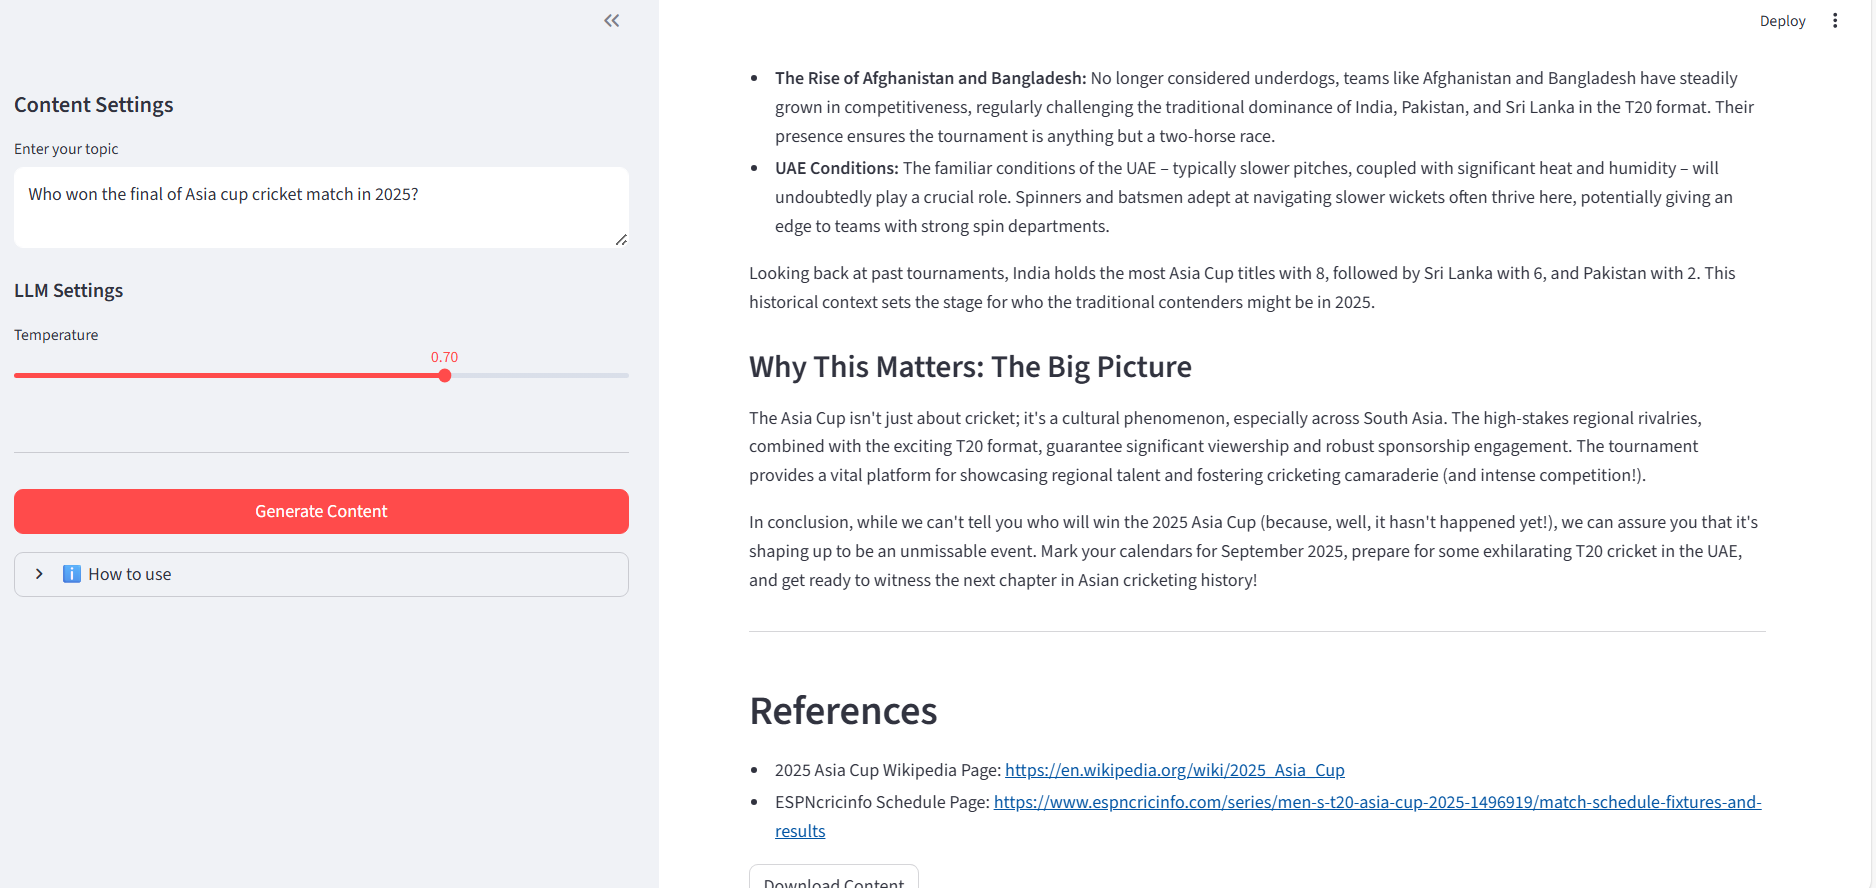

---
### **Crew Completion**
`Crew Execution Completed` <br> `Name`: crew <br> `ID`: ba2bc432-1508-4a9d-85eb-7b89868381ff <br> `Final Output`: # Get Ready for the 2025 Asia Cup: What We Know So Far!  <br>

Cricket fans, mark your calendars! The highly anticipated Asia Cup is making its return in 2025, promising another thrilling display of regional      │
│  cricketing prowess. However, before you start searching for match results or anointing a winner, let's clear up some crucial details: as of June      │
│  2024, the **2025 Asia Cup has not yet taken place**. Any news about a champion is pure speculation! This post will dive into everything we *do* know  │
│  about the upcoming tournament, from its confirmed schedule and format to the exciting trends set to shape the competition.                            │
│                                                                                                                                                        │
│  ### The Basics: When and Where?                                                                                                                       │
│                                                                                                                                                        │
│  Get ready for some scorching cricket action in the desert! The 17th edition of the Asia Cup is officially scheduled to ignite the pitches of the      │
│  **United Arab Emirates (UAE)** from **September 9 to September 28, 2025** [Source:                                                                    │
│  [https://en.wikipedia.org/wiki/2025_Asia_Cup](https://en.wikipedia.org/wiki/2025_Asia_Cup)]. That's nearly three weeks of top-tier Asian cricket to   │
│  look forward to! The tournament will be played in the **Twenty20 International (T20I)** format, a strategic choice that aligns perfectly with the     │
│  fast-paced nature of modern cricket and its growing global appeal [Source:                                                                            │
│  [https://www.espncricinfo.com/series/men-s-t20-asia-cup-2025-1496919/match-schedule-fixtures-and-results](https://www.espncricinfo.com/series/men-s-  │
│  t20-asia-cup-2025-1496919/match-schedule-fixtures-and-results)].                                                                                      │
│                                                                                                                                                        │
│  So, to reiterate, while the excitement is building, the scoreboard for the 2025 Asia Cup is currently blank. The eventual winner will be decided      │
│  only after fierce competition next year!                                                                                                              │
│                                                                                                                                                        │
│  ### The T20 Takeover: What to Expect on the Field                                                                                                     │
│                                                                                                                                                        │
│  The cricket world has unequivocally embraced the T20 format, and the 2025 Asia Cup will be no exception. This shift means we can expect highly        │
│  specialized T20 tactics, explosive batting, and razor-sharp fielding. Here’s a look at some broader cricketing trends that will undoubtedly           │
│  influence the tournament:                                                                                                                             │
│                                                                                                                                                        │
│  *   **T20 Dominance:** The relentless march of T20 cricket continues. Teams are honing their strategies specifically for this format, impacting       │
│  everything from player selection to on-field execution.                                                                                               │
│  *   **Data Analytics in Action:** Prepare for a data-driven tournament! Teams increasingly leverage advanced analytics to dissect opponents, track    │
│  player performance, and make crucial strategic decisions in real-time.                                                                                │
│  *   **Franchise League Impact:** The explosion of T20 franchise leagues worldwide (think IPL, PSL, BBL) means players arrive with extensive           │
│  experience in high-pressure T20 scenarios. This elevates the overall standard, making for an even more competitive international spectacle.           │
│  *   **Player Workload Management:** With a packed international calendar, national teams face the constant challenge of managing player workloads to  │
│  prevent injuries and ensure peak performance. Expect careful rotation and strategic resting of key players.                                           │
│  *   **Hybrid Pitches:** Keep an eye out for potential innovations like hybrid pitches. These surfaces, combining natural grass with artificial        │
│  fibers, could offer more consistent playing conditions, influencing batting and bowling strategies.                                                   │
│                                                                                                                                                        │
│  ### Rivalries and Rising Stars: Who to Watch                                                                                                          │
│                                                                                                                                                        │
│  While it’s too early for specific predictions, the Asia Cup always brings with it iconic rivalries and the emergence of new talent.                   │
│                                                                                                                                                        │
│  *   **The India-Pakistan Blockbuster:** This clash remains the undisputed highlight of any Asia Cup. The historical rivalry between these two         │
│  cricketing giants guarantees massive viewership and electrifying atmosphere, dominating discussions long before a ball is bowled.                     │
│  *   **The Rise of Afghanistan and Bangladesh:** No longer considered underdogs, teams like Afghanistan and Bangladesh have steadily grown in          │
│  competitiveness, regularly challenging the traditional dominance of India, Pakistan, and Sri Lanka in the T20 format. Their presence ensures the      │
│  tournament is anything but a two-horse race.                                                                                                          │
│  *   **UAE Conditions:** The familiar conditions of the UAE – typically slower pitches, coupled with significant heat and humidity – will undoubtedly  │
│  play a crucial role. Spinners and batsmen adept at navigating slower wickets often thrive here, potentially giving an edge to teams with strong spin  │
│  departments.                                                                                                                                          │
│                                                                                                                                                        │
│  Looking back at past tournaments, India holds the most Asia Cup titles with 8, followed by Sri Lanka with 6, and Pakistan with 2. This historical     │
│  context sets the stage for who the traditional contenders might be in 2025.                                                                           │
│                                                                                                                                                        │
│  ### Why This Matters: The Big Picture                                                                                                                 │
│                                                                                                                                                        │
│  The Asia Cup isn't just about cricket; it's a cultural phenomenon, especially across South Asia. The high-stakes regional rivalries, combined with    │
│  the exciting T20 format, guarantee significant viewership and robust sponsorship engagement. The tournament provides a vital platform for showcasing  │
│  regional talent and fostering cricketing camaraderie (and intense competition!).                                                                      │
│                                                                                                                                                        │
│  In conclusion, while we can't tell you who will win the 2025 Asia Cup (because, well, it hasn't happened yet!), we can assure you that it's shaping   │
│  up to be an unmissable event. Mark your calendars for September 2025, prepare for some exhilarating T20 cricket in the UAE, and get ready to witness  │
│  the next chapter in Asian cricketing history!                                                                                                         │
│                                                                                                                                                        │
│  ---                                                                                                                                                   │
│                                                                                                                                                        │
│  ## References                                                                                                                                         │
│                                                                                                                                                        │
│  *   2025 Asia Cup Wikipedia Page: [https://en.wikipedia.org/wiki/2025_Asia_Cup](https://en.wikipedia.org/wiki/2025_Asia_Cup)                          │
│  *   ESPNcricinfo Schedule Page:                                                                                                                       │
│  [https://www.espncricinfo.com/series/men-s-t20-asia-cup-2025-1496919/match-schedule-fixtures-and-results](https://www.espncricinfo.com/series/men-s-  │
│  t20-asia-cup-2025-1496919/match-schedule-fixtures-and-results) 

---

## `Streamlitapp.output-3`
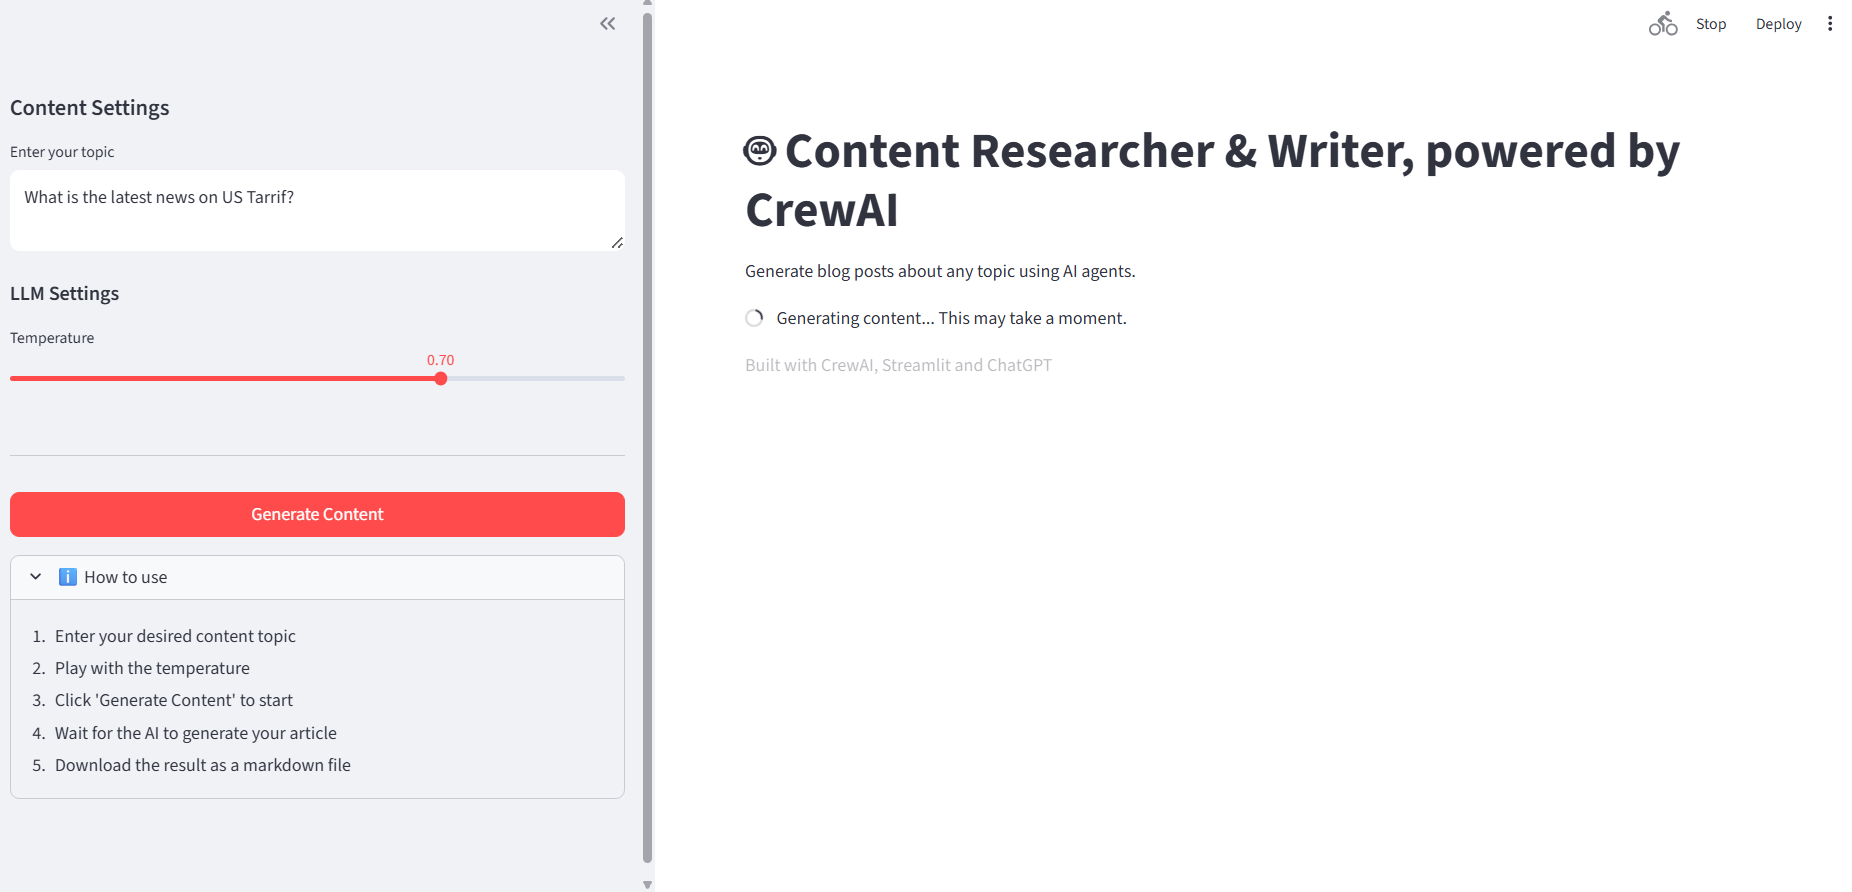 <br><br> 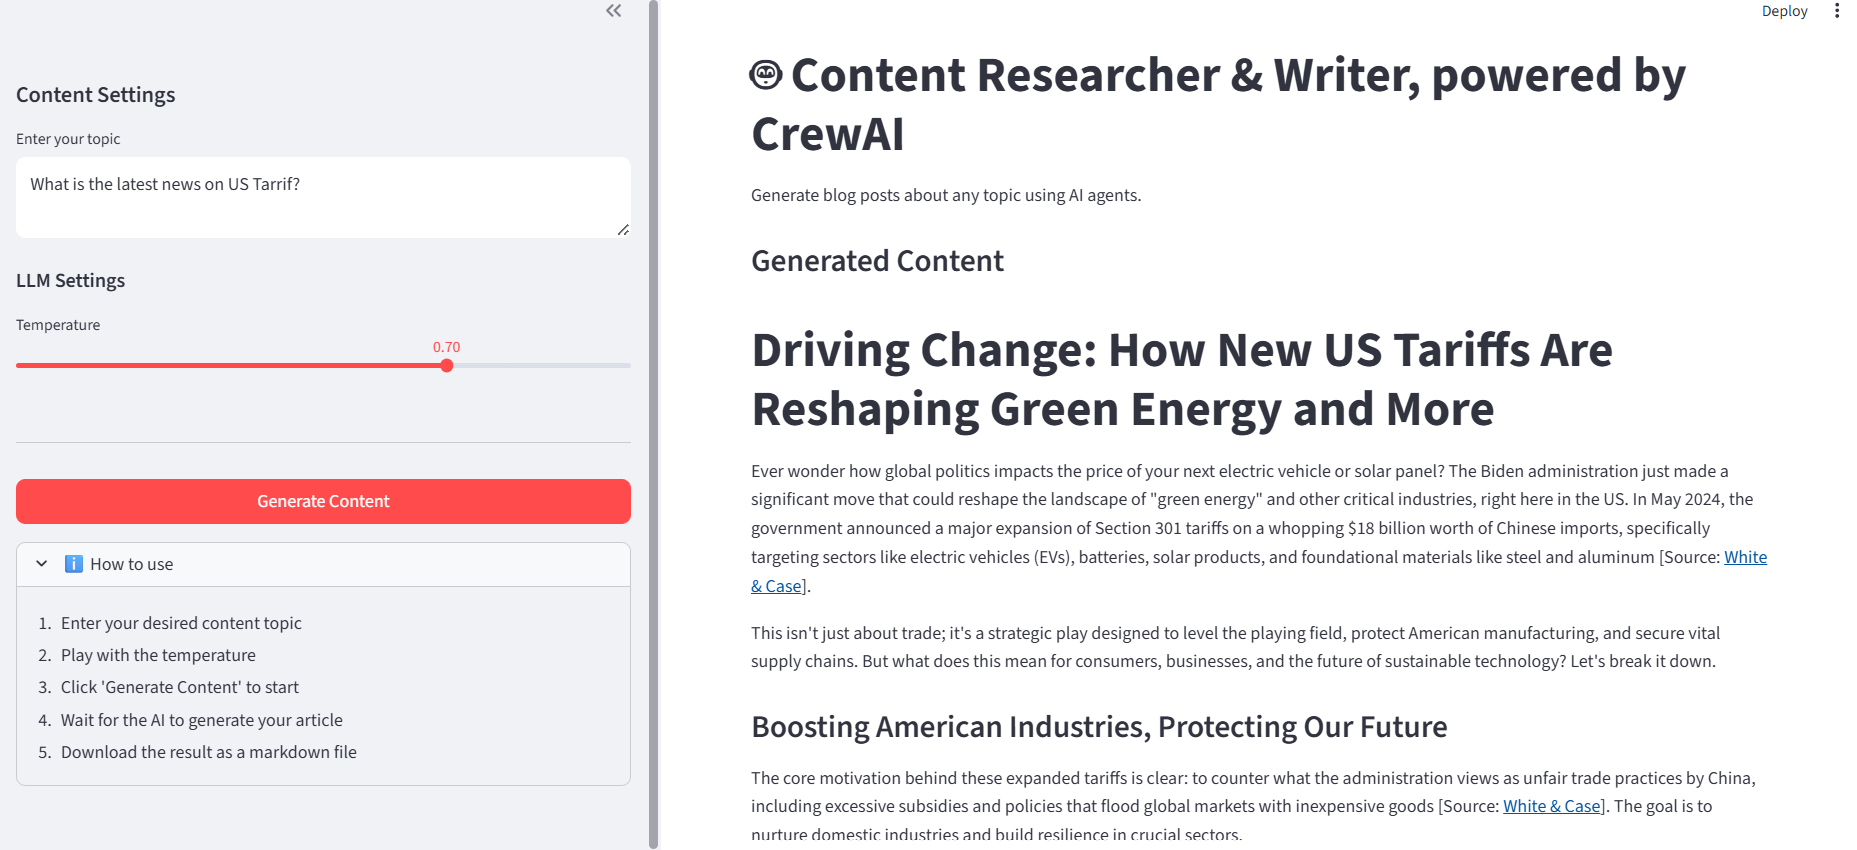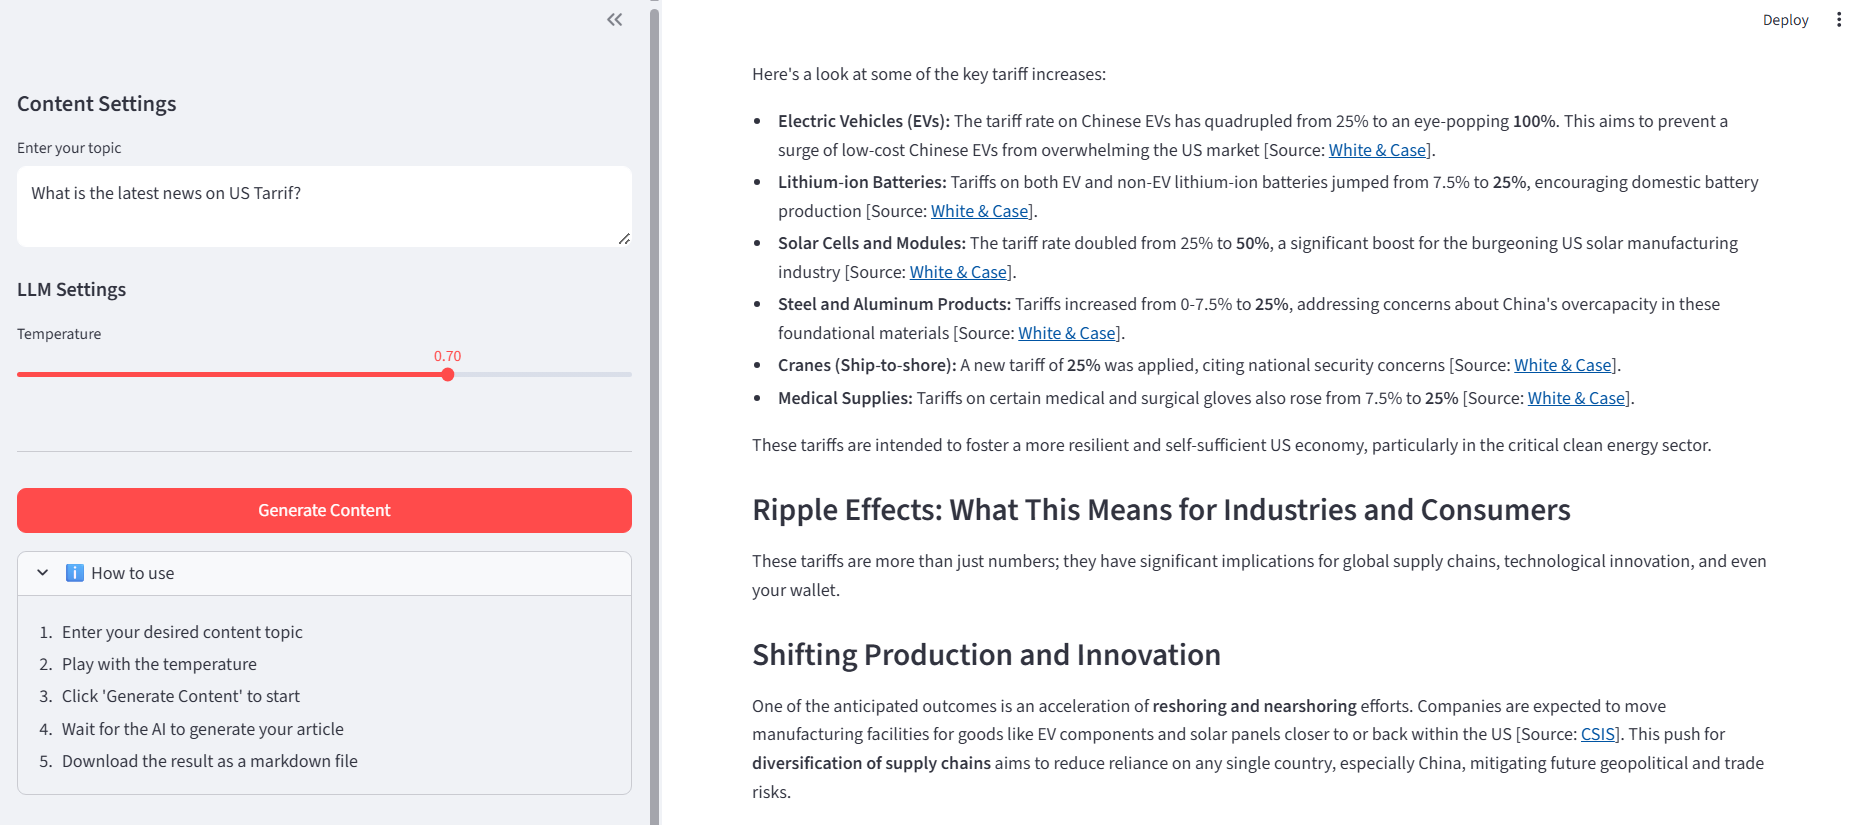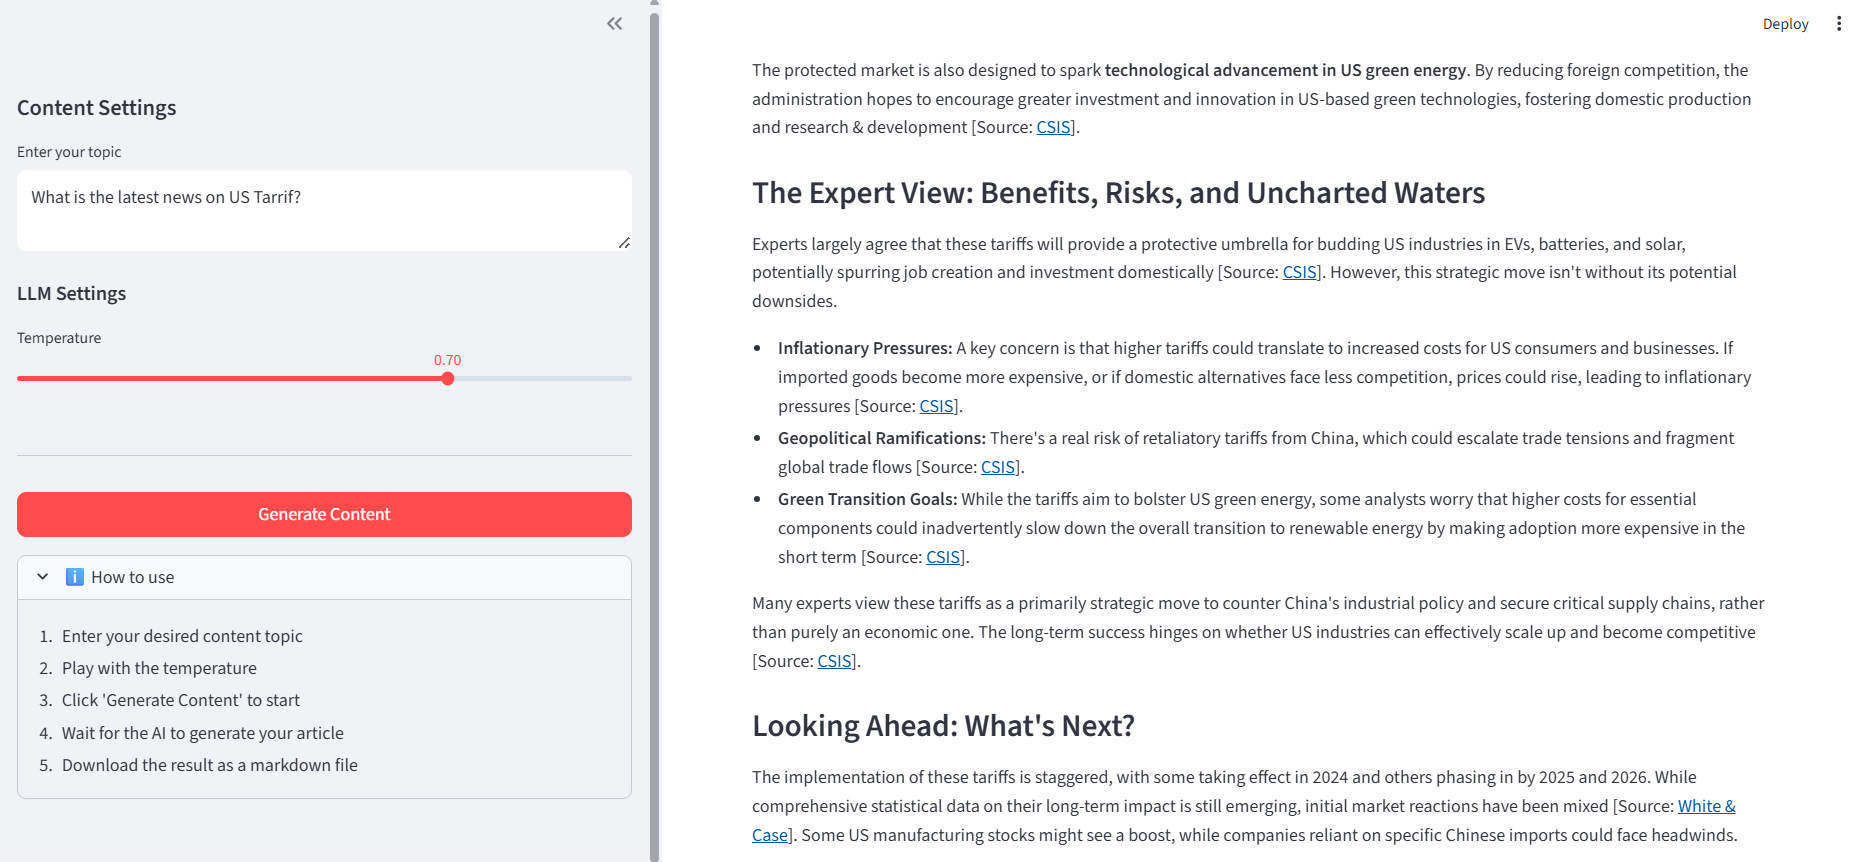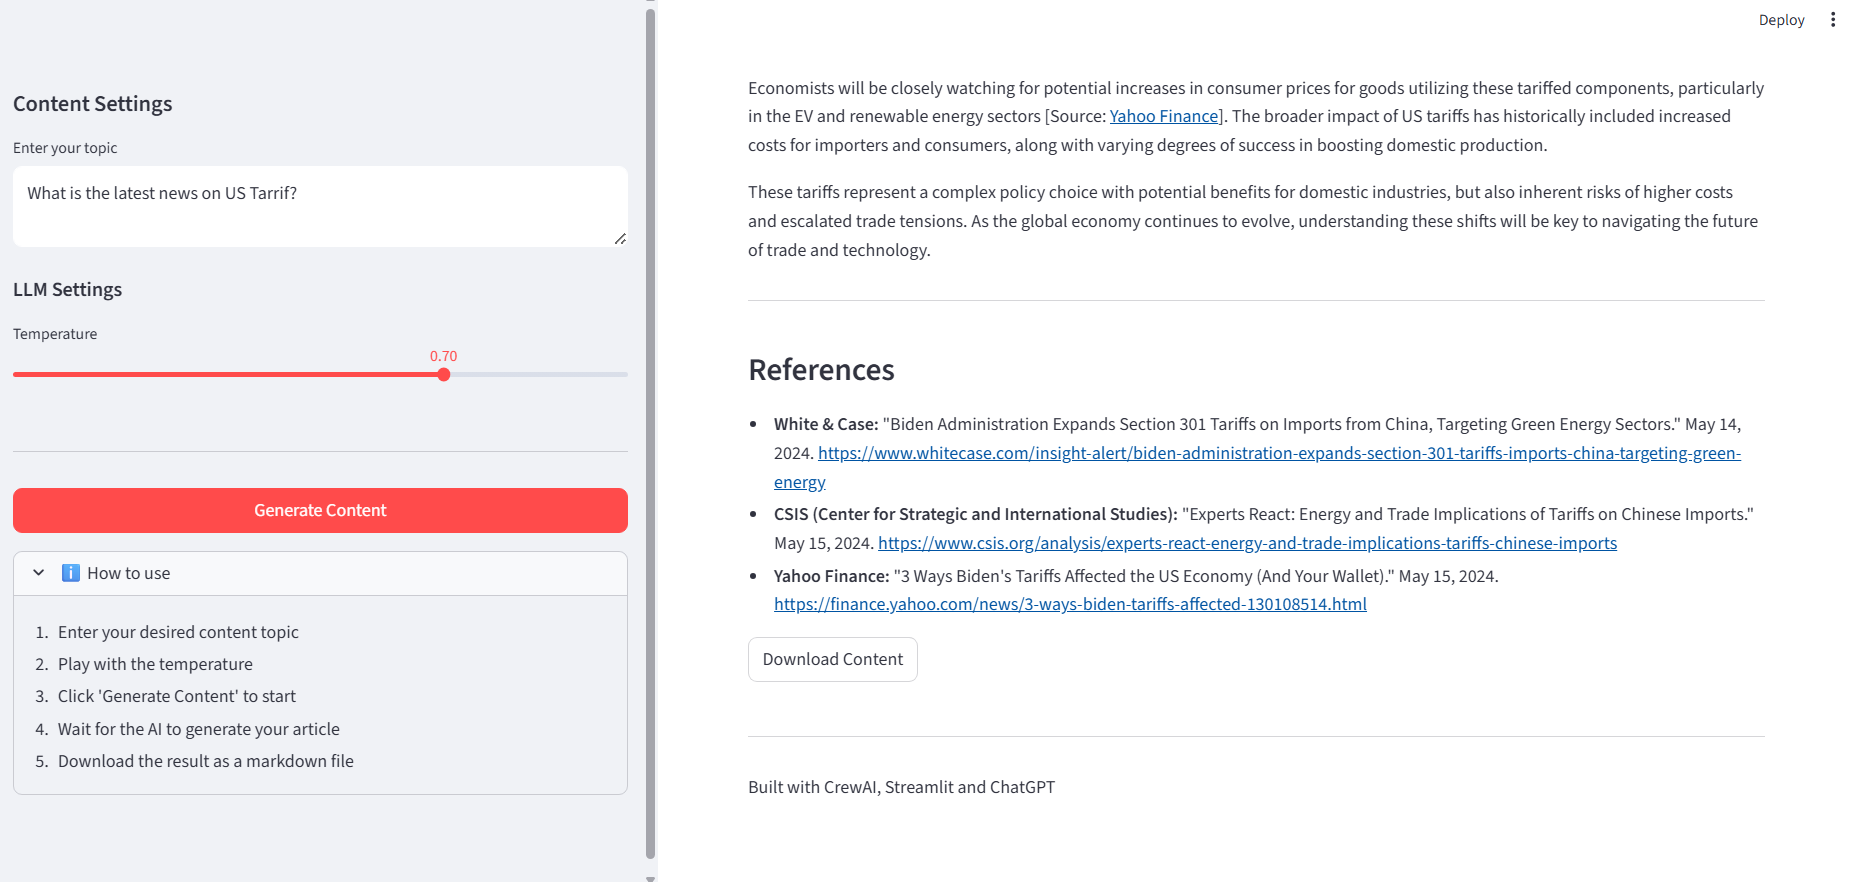

---
### **Crew Completion**
Crew Execution Completed                                                                                                                              │
│  Name: crew                                                                                                                                            │
│  ID: 920dfe70-a748-4715-a663-3515f440f9dc                                                                                                              │
│  Tool Args:                                                                                                                                            │
│  Final Output: # U.S. Tariffs on China: A Deep Dive into Biden's Latest Economic Strategy                                                              │
│                                                                                                                                                        │
│  Hold onto your hats, because the global trade landscape just got a significant shake-up! On September 13, 2024, the Biden administration finalized a  │
│  wave of substantial tariff increases on a diverse range of Chinese imports. This isn't just about trade; it's a strategic move following a four-year  │
│  review of Section 301 tariffs, aimed squarely at protecting vital American industries and pushing back against what the U.S. terms China's "unfair    │
│  trade practices." From electric vehicles to medical supplies, these hikes signal a firm stance, but what do they truly mean for consumers,            │
│  businesses, and the future of international relations? Let's break it down.                                                                           │
│                                                                                                                                                        │
│  ### A Closer Look at the New Tariffs                                                                                                                  │
│                                                                                                                                                        │
│  The Office of the United States Trade Representative (USTR) officially confirmed these modifications, concluding a comprehensive review mandated by   │
│  statute [Source:                                                                                                                                      │
│  https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutory-four-yea  │
│  r-review](https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutor  │
│  y-four-year-review). These aren't minor tweaks; they're steep increases targeting strategic sectors:                                                  │
│                                                                                                                                                        │
│  *   **Electric Vehicles (EVs):** Get ready for a monumental jump! Duties on certain EV imports are set to increase to a staggering 100% from 25%,     │
│  effective September 27, 2024.                                                                                                                         │
│  *   **Lithium-ion Batteries:** Both EV and non-EV lithium-ion batteries will see duties rise to 25% from 7.5%, starting September 27, 2024, for EV    │
│  batteries and in 2026 for non-EV batteries.                                                                                                           │
│  *   **Solar Cells:** The clean energy sector will feel the impact, with duties doubling to 50% from 25%, also effective September 27, 2024.           │
│  *   **Steel and Aluminum Products:** Tariffs on these foundational materials are set to more than triple, reaching 25% from 7.5%, effective           │
│  September 27, 2024.                                                                                                                                   │
│  *   **Semiconductors:** A critical component of modern technology, semiconductors will see tariffs increase to 50% from 25% in 2025.                  │
│  *   **Medical Products:** Syringes and needles, essential medical items, will face a significant hike from 0% to 50% duties, effective September 27,  │
│  2024. Other medical and personal protective equipment (PPE) will follow suit in 2026.                                                                 │
│  *   **Ship-to-shore Cranes:** These large port machines will also see duties rise to 25% from 0%, effective September 27, 2024 [Source:               │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/).                                                                                                    │
│                                                                                                                                                        │
│  ### Why Now? The Strategy Behind the Tariffs                                                                                                          │
│                                                                                                                                                        │
│  These tariffs aren't arbitrary; they're a cornerstone of a broader U.S. strategy focused on national security and economic resilience. The            │
│  administration's rationale is clear: to build robust domestic supply chains and lessen dependence on China for critical goods, particularly in        │
│  cutting-edge green energy technologies and advanced manufacturing [Source:                                                                            │
│  https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutory-four-yea  │
│  r-review](https://ustr.gov/about-us/policy-offices/press-office/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-follo  │
│  wing-statutory-four-year-review).                                                                                                                     │
│                                                                                                                                                        │
│  The USTR's review concluded that China's practices concerning technology transfer, intellectual property, and innovation continue to harm U.S.        │
│  economic interests. By hiking tariffs, the administration aims to protect American industries like automotive, steel, and solar from what it          │
│  considers "dumping" and heavily subsidized competition from China. This move is designed to foster domestic job creation and spur technological       │
│  innovation within the U.S. and among its allies, a strategy often referred to as "reshoring" or "friendshoring" [Source:                              │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/). The significant tariffs on EVs, batteries, and solar cells specifically highlight a drive to       │
│  dominate the burgeoning green energy sector. Furthermore, tariffs on medical supplies like syringes are a direct response to lessons learned during   │
│  the COVID-19 pandemic, aiming to secure vital healthcare supply chains [Source:                                                                       │
│  https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutory-four-yea  │
│  r-review](https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutor  │
│  y-four-year-review).                                                                                                                                  │
│                                                                                                                                                        │
│  ### The Ripple Effect: Potential Impacts and Concerns                                                                                                 │
│                                                                                                                                                        │
│  While the administration champions these tariffs as a necessary defense, not everyone is convinced they'll be a smooth ride. Some economists and      │
│  industry groups are sounding the alarm about potential inflationary pressures. If businesses pass on increased import costs to consumers, we could    │
│  see higher prices domestically. Downstream industries, particularly those relying on Chinese components (like U.S. auto parts makers), might face     │
│  elevated costs and supply chain disruptions [Source:                                                                                                  │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/).                                                                                                    │
│                                                                                                                                                        │
│  Analysts also note the tariffs arrive in a critical U.S. election year, viewing them as a strategic political move to demonstrate a tough stance on   │
│  China and appeal to voters concerned about manufacturing jobs and economic competition. Unsurprisingly, experts anticipate retaliation from Beijing,  │
│  potentially escalating trade tensions as China has historically responded with its own duties on American goods [Source:                              │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/).                                                                                                    │
│                                                                                                                                                        │
│  The USTR's own economic analyses, regarding previous Section 301 actions, "generally find that tariffs (primarily PRC retaliation) have had small     │
│  negative effects on U.S. aggregate economic welfare." However, they also concluded that these actions "reduced some of the exposure of U.S. persons   │
│  and businesses to these unfair trade practices" [Source:                                                                                              │
│  https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutory-four-yea  │
│  r-review](https://ustr.gov/about-us/policy-offices/press-office/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-follo  │
│  wing-statutory-four-year-review). This highlights an ongoing debate about their long-term economic effectiveness versus their strategic benefits.     │
│                                                                                                                                                        │
│  ### Beyond the Headlines: What These Tariffs Mean                                                                                                     │
│                                                                                                                                                        │
│  Despite existing tariffs, China remains a significant source of imports for the U.S. across various categories. Interestingly, the 100% EV tariff is  │
│  largely pre-emptive, as very few Chinese-made EVs currently enter the U.S. market [Source:                                                            │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/). However, the increased duties on batteries could still have broader implications for the EV        │
│  market as a whole.                                                                                                                                    │
│                                                                                                                                                        │
│  The increased tariffs on steel and aluminum are designed to bolster domestic industries that have long struggled against global oversupply,           │
│  especially from China. Similarly, doubling solar cell tariffs aims to support U.S. solar manufacturing, which has found it hard to compete with       │
│  lower-cost Chinese producers [Source:                                                                                                                 │
│  https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/](https://www.reuters.com/business/us-locks-steep-c  │
│  hina-tariff-hikes-many-start-sept-27-2024-09-13/). These moves are part of an ongoing effort to address the U.S. trade deficit with China, though     │
│  the effectiveness of tariffs alone in significantly altering the overall trade balance remains a subject of considerable debate among economists.     │
│                                                                                                                                                        │
│  Ultimately, these tariffs represent a bold statement by the Biden administration – a commitment to prioritizing domestic industries, strengthening    │
│  critical supply chains, and challenging China's economic dominance. The coming months will reveal the true extent of their impact on global trade,    │
│  consumer prices, and the ongoing geopolitical chess match.                                                                                            │
│                                                                                                                                                        │
│  ### References                                                                                                                                        │
│                                                                                                                                                        │
│  *   [USTR Press Release: USTR Finalizes Action on China Tariffs Following Statutory Four-Year                                                         │
│  Review](https://ustr.gov/about-us/policy-offices/press-office/press-releases/2024/september/ustr-finalizes-action-china-tariffs-following-statutory-  │
│  four-year-review) (September 13, 2024)                                                                                                                │
│  *   [Reuters Article: US locks in steep China tariff hikes, some industries                                                                           │
│  warn...](https://www.reuters.com/business/us-locks-steep-china-tariff-hikes-many-start-sept-27-2024-09-13/) (September 13, 2024)    


---